**cnn**

In [1]:
import os
import numpy as np
from glob import glob
import cv2
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Paths to directories (Modify these paths based on your dataset location)
data_dir_train_antiviral = "/kaggle/input/ennavia-b-spectrogram-images-pi-based/spectrogram images/antiviral training images"
data_dir_test_antiviral = "/kaggle/input/ennavia-b-spectrogram-images-pi-based/spectrogram images/antiviral testing images"
,
data_dir_train_non_antiviral = "/kaggle/input/ennavia-b-spectrogram-images-pi-based/spectrogram images/random-seq-non-antiviral training images"
data_dir_test_non_antiviral = "/kaggle/input/ennavia-b-spectrogram-images-pi-based/spectrogram images/random-seq-non-antiviral testing images"

# Image dimensions
IMG_HEIGHT, IMG_WIDTH = 128, 128  

# Function to load and preprocess images
def load_images_from_directory(directory, label):
    images, labels = [], []
    files = glob(os.path.join(directory, "*.png"))  # Assumes images are in PNG format
    for file in files:
        img = cv2.imread(file)
        if img is None:
            continue
        img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))  # Resize to 128x128
        img = img / 255.0  # Normalize pixel values
        images.append(img)
        labels.append(label)  # Assign the given label (0 or 1)
    return np.array(images), np.array(labels)

# Load training and testing datasets
X_train_antiviral, y_train_antiviral = load_images_from_directory(data_dir_train_antiviral, label=1)
X_test_antiviral, y_test_antiviral = load_images_from_directory(data_dir_test_antiviral, label=1)

X_train_non_antiviral, y_train_non_antiviral = load_images_from_directory(data_dir_train_non_antiviral, label=0)
X_test_non_antiviral, y_test_non_antiviral = load_images_from_directory(data_dir_test_non_antiviral, label=0)

# Combine both classes
X_train = np.concatenate((X_train_antiviral, X_train_non_antiviral), axis=0)
y_train = np.concatenate((y_train_antiviral, y_train_non_antiviral), axis=0)

X_test = np.concatenate((X_test_antiviral, X_test_non_antiviral), axis=0)
y_test = np.concatenate((y_test_antiviral, y_test_non_antiviral), axis=0)

# Shuffle dataset
indices = np.arange(X_train.shape[0])
np.random.shuffle(indices)
X_train, y_train = X_train[indices], y_train[indices]

indices_test = np.arange(X_test.shape[0])
np.random.shuffle(indices_test)
X_test, y_test = X_test[indices_test], y_test[indices_test]

def build_cnn_model(input_shape):
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(256, (3, 3), activation='relu'),  # Additional layer
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')  # Binary classification
    ])
    
    lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate=0.001, decay_steps=5000, decay_rate=0.9, staircase=True
    )
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)
    
    model.compile(optimizer=optimizer, 
                  loss='binary_crossentropy', 
                  metrics=['accuracy'])
    return model

# Instantiate model
model = build_cnn_model((IMG_HEIGHT, IMG_WIDTH, 3))

# Callbacks
early_stopping = callbacks.EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True)
model_checkpoint = callbacks.ModelCheckpoint("best_cnn_model.keras", monitor='val_accuracy', save_best_only=True)

# Train model
history = model.fit(
    X_train, y_train, batch_size=32, epochs=200,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping, model_checkpoint],
    verbose=1
)

# Load best model and evaluate
model.load_weights("best_cnn_model.keras")
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy: {test_accuracy * 100:.2f}%")

# Save model in Kaggle
tf.keras.models.save_model(model, "/kaggle/working/final_cnn_model.keras")
print("Model saved successfully in /kaggle/working/")

2025-05-25 09:54:14.580502: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1748166855.047496      35 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1748166855.164486      35 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1748166891.140403      35 gpu_device.cc:2022] Created device /job:localhost/repl

Epoch 1/200


I0000 00:00:1748166896.642335      98 service.cc:148] XLA service 0x7d1e34006c50 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1748166896.643934      98 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1748166896.643966      98 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1748166897.142802      98 cuda_dnn.cc:529] Loaded cuDNN version 90300


10/34 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.4930 - loss: 4.7172

I0000 00:00:1748166901.883200      98 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


34/34 ━━━━━━━━━━━━━━━━━━━━ 13s 142ms/step - accuracy: 0.5161 - loss: 3.2100 - val_accuracy: 0.4957 - val_loss: 0.8120
Epoch 2/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.5158 - loss: 0.7669 - val_accuracy: 0.5043 - val_loss: 0.7007
Epoch 3/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.5095 - loss: 0.6981 - val_accuracy: 0.7043 - val_loss: 0.6242
Epoch 4/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.6281 - loss: 0.6762 - val_accuracy: 0.6696 - val_loss: 0.6502
Epoch 5/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.7162 - loss: 0.6341 - val_accuracy: 0.7652 - val_loss: 0.5844
Epoch 6/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.7775 - loss: 0.5617 - val_accuracy: 0.7478 - val_loss: 0.5407
Epoch 7/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.8106 - loss: 0.4764 - val_accuracy: 0.7739 - val_loss: 0.5191
Epoch 8/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.8459 - loss: 0.4489 - val_accuracy: 0.8174 - val

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 126ms/step


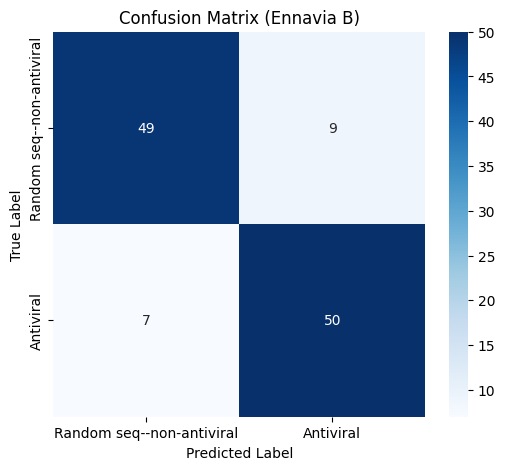


🔹 Classification Report:

                           precision    recall  f1-score   support

Random seq--non-antiviral       0.88      0.84      0.86        58
                Antiviral       0.85      0.88      0.86        57

                 accuracy                           0.86       115
                macro avg       0.86      0.86      0.86       115
             weighted avg       0.86      0.86      0.86       115



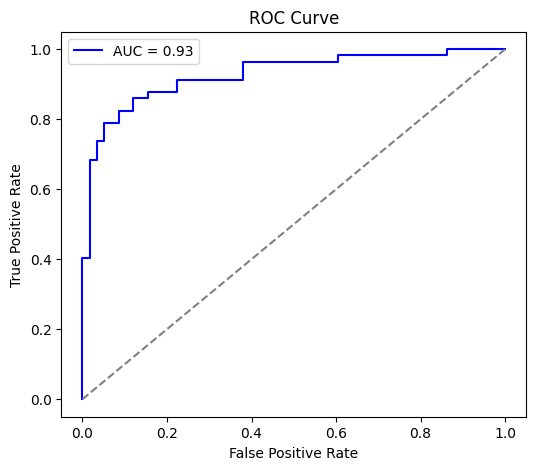

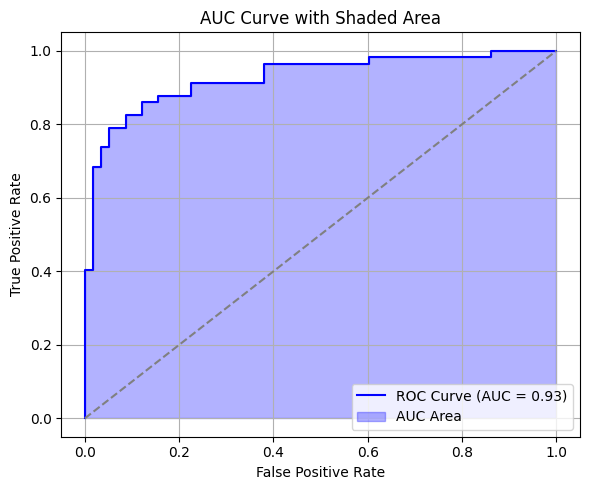

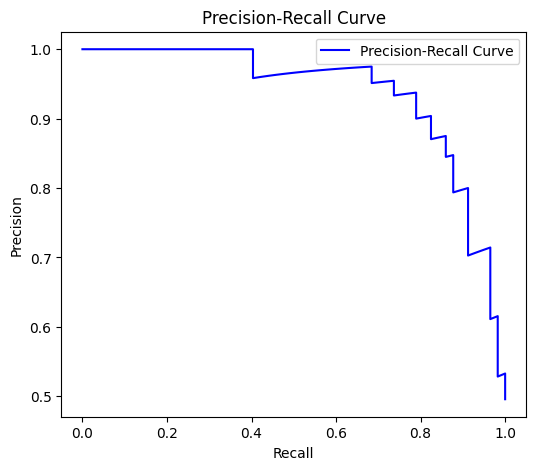

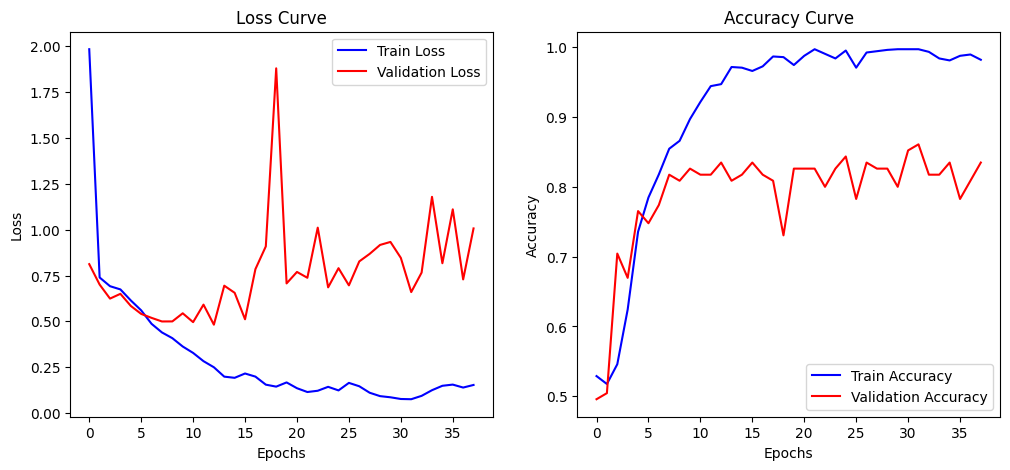

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
4/4 ━━━━━━━━

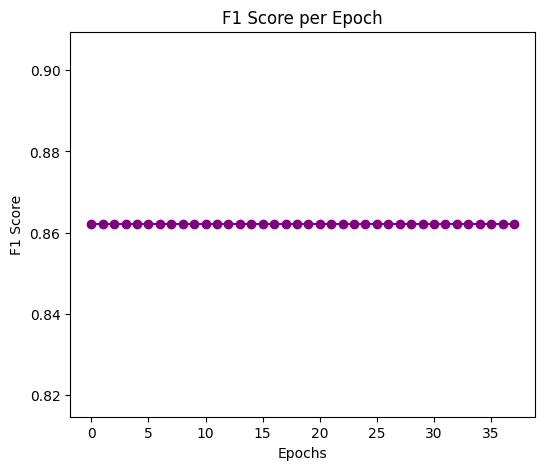

Cohen’s Kappa Score: 0.72
Matthews Correlation Coefficient (MCC): 0.72


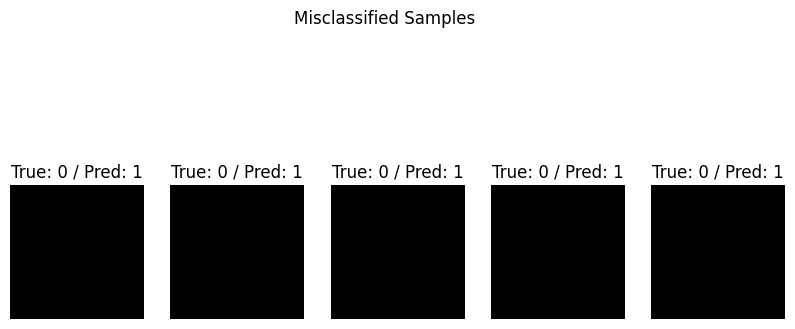


🔟 Performance Metrics Summary Table (For Research Paper)

   Metric  Score
 Accuracy 0.8609
Precision 0.8475
   Recall 0.8772
 F1-score 0.8621
      AUC 0.9271
      MCC 0.7222
   G-mean 0.8609


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_curve, auc,
    precision_recall_curve, f1_score, cohen_kappa_score, matthews_corrcoef,
    accuracy_score, precision_score, recall_score
)
import pandas as pd
import random

# Predict probabilities and binary labels
y_pred_probs = model.predict(X_test)
y_pred = (y_pred_probs > 0.5).astype(int)

# 🔹 1️⃣ Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Random seq--non-antiviral", "Antiviral"],
            yticklabels=["Random seq--non-antiviral", "Antiviral"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (Ennavia B)")
plt.show()

# 🔹 2️⃣ Classification Report
print("\n🔹 Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=["Random seq--non-antiviral", "Antiviral"]))

# 🔹 3️⃣ ROC Curve & AUC Score
fpr, tpr, _ = roc_curve(y_test, y_pred_probs)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='blue', label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

# 🌟 Extra: AUC Curve with Shaded Area
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.fill_between(fpr, tpr, alpha=0.3, color='blue', label='AUC Area')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('AUC Curve with Shaded Area')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

# 🔹 4️⃣ Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_probs)
plt.figure(figsize=(6, 5))
plt.plot(recall, precision, color='blue', label='Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

# 🔹 5️⃣ Training Loss & Accuracy Curves
plt.figure(figsize=(12, 5))

# Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='red')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy Curve')
plt.legend()
plt.show()

# 🔹 6️⃣ F1 Score per Epoch
f1_scores = [f1_score(y_test, (model.predict(X_test) > 0.5).astype(int)) for _ in range(len(history.history['loss']))]
plt.figure(figsize=(6, 5))
plt.plot(f1_scores, color='purple', marker='o')
plt.xlabel('Epochs')
plt.ylabel('F1 Score')
plt.title('F1 Score per Epoch')
plt.show()

# 🔹 7️⃣ Cohen’s Kappa Score
kappa_score = cohen_kappa_score(y_test, y_pred)
print(f"Cohen’s Kappa Score: {kappa_score:.2f}")

# 🔹 8️⃣ Matthews Correlation Coefficient (MCC)
mcc = matthews_corrcoef(y_test, y_pred)
print(f"Matthews Correlation Coefficient (MCC): {mcc:.2f}")

# 🔹 9️⃣ Error Analysis (Misclassified Samples)
misclassified_idx = np.where(y_pred.flatten() != y_test.flatten())[0]
if len(misclassified_idx) > 5:
    misclassified_idx = random.sample(list(misclassified_idx), 5)

plt.figure(figsize=(10, 5))
for i, idx in enumerate(misclassified_idx):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_test[idx].astype("uint8"))
    plt.title(f"True: {y_test[idx]} / Pred: {y_pred[idx][0]}")
    plt.axis("off")
plt.suptitle("Misclassified Samples")
plt.show()

# 🔟 Performance Metrics Summary Table (for Research Paper)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
accuracy = accuracy_score(y_test, y_pred)
precision_val = precision_score(y_test, y_pred)
recall_val = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
sensitivity = recall_val
specificity = tn / (tn + fp)
gmean = np.sqrt(sensitivity * specificity)

performance_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "AUC", "MCC", "G-mean"],
    "Score": [accuracy, precision_val, recall_val, f1, roc_auc, mcc, gmean]
})

print("\n🔟 Performance Metrics Summary Table (For Research Paper)\n")
print(performance_df.round(4).to_string(index=False))


**cnn+SE**

In [3]:
import os
import numpy as np
from glob import glob
import cv2
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, regularizers

# Paths to directories (Modify these paths based on your dataset location)
data_dir_train_antiviral = "/kaggle/input/ennavia-b-spectrogram-images-pi-based/spectrogram images/antiviral training images"
data_dir_test_antiviral = "/kaggle/input/ennavia-b-spectrogram-images-pi-based/spectrogram images/antiviral testing images"
,
data_dir_train_non_antiviral = "/kaggle/input/ennavia-b-spectrogram-images-pi-based/spectrogram images/random-seq-non-antiviral training images"
data_dir_test_non_antiviral = "/kaggle/input/ennavia-b-spectrogram-images-pi-based/spectrogram images/random-seq-non-antiviral testing images"



# Image dimensions
IMG_HEIGHT, IMG_WIDTH = 128, 128  

# Function to load and preprocess images
def load_images_from_directory(directory, label):
    images, labels = [], []
    files = glob(os.path.join(directory, "*.png"))  # Assumes images are in PNG format
    for file in files:
        img = cv2.imread(file)
        if img is None:
            continue
        img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))  # Resize to 128x128
        img = img / 255.0  # Normalize pixel values
        images.append(img)
        labels.append(label)  # Assign the given label (0 or 1)
    return np.array(images), np.array(labels)

# Load training and testing datasets
X_train_antiviral, y_train_antiviral = load_images_from_directory(data_dir_train_antiviral, label=1)
X_test_antiviral, y_test_antiviral = load_images_from_directory(data_dir_test_antiviral, label=1)

X_train_non_antiviral, y_train_non_antiviral = load_images_from_directory(data_dir_train_non_antiviral, label=0)
X_test_non_antiviral, y_test_non_antiviral = load_images_from_directory(data_dir_test_non_antiviral, label=0)

# Combine both classes
X_train = np.concatenate((X_train_antiviral, X_train_non_antiviral), axis=0)
y_train = np.concatenate((y_train_antiviral, y_train_non_antiviral), axis=0)

X_test = np.concatenate((X_test_antiviral, X_test_non_antiviral), axis=0)
y_test = np.concatenate((y_test_antiviral, y_test_non_antiviral), axis=0)

# Shuffle dataset
indices = np.arange(X_train.shape[0])
np.random.shuffle(indices)
X_train, y_train = X_train[indices], y_train[indices]

indices_test = np.arange(X_test.shape[0])
np.random.shuffle(indices_test)
X_test, y_test = X_test[indices_test], y_test[indices_test]

# Squeeze and Excitation Block
def squeeze_excite_block(input_tensor, ratio=16):
    """Squeeze and Excitation block to enhance feature representation"""
    filters = input_tensor.shape[-1]
    
    # Squeeze operation
    se = layers.GlobalAveragePooling2D()(input_tensor)
    se = layers.Dense(filters // ratio, activation="relu")(se)
    se = layers.Dense(filters, activation="sigmoid")(se)
    
    # Excitation operation (Rescale feature maps)
    se = layers.Reshape((1, 1, filters))(se)
    output_tensor = layers.multiply([input_tensor, se])
    return output_tensor

# Define CNN Model with SE Attention
def build_se_cnn(input_shape):
    inputs = layers.Input(shape=input_shape)

    # Block 1
    x = layers.Conv2D(32, (5, 5), activation='relu', padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = squeeze_excite_block(x)  # Apply SE block
    x = layers.MaxPooling2D((2, 2))(x)

    # Block 2
    x = layers.Conv2D(64, (5, 5), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = squeeze_excite_block(x)  # Apply SE block
    x = layers.MaxPooling2D((2, 2))(x)

    # Block 3 with Residual Connection and SE
    res = layers.Conv2D(128, (3, 3), padding='same')(x)
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = squeeze_excite_block(x)  # Apply SE block
    x = layers.Add()([x, res])  # Residual Connection
    x = layers.MaxPooling2D((2, 2))(x)

    # Block 4
    x = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = squeeze_excite_block(x)  # Apply SE block
    x = layers.MaxPooling2D((2, 2))(x)

    # Global Average Pooling instead of Flatten
    x = layers.GlobalAveragePooling2D()(x)

    # Fully Connected Layer
    x = layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.01))(x)
    x = layers.Dropout(0.5)(x)

    # Output Layer
    outputs = layers.Dense(1, activation='sigmoid')(x)

    # Define Model
    model = models.Model(inputs, outputs)

    # Learning Rate Scheduler
    lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate=0.001, decay_steps=5000, decay_rate=0.9, staircase=True
    )
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)

    # Compile Model
    model.compile(optimizer=optimizer, 
                  loss='binary_crossentropy', 
                  metrics=['accuracy'])
    return model

# Instantiate model
model = build_se_cnn((IMG_HEIGHT, IMG_WIDTH, 3))

# Callbacks
early_stopping = callbacks.EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True)
model_checkpoint = callbacks.ModelCheckpoint("best_se_cnn.keras", monitor='val_accuracy', save_best_only=True)

# Train model
history = model.fit(
    X_train, y_train, batch_size=32, epochs=200,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping, model_checkpoint],
    verbose=1
)

# Load best model and evaluate
model.load_weights("best_se_cnn.keras")
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy: {test_accuracy * 100:.2f}%")

# Save model in Kaggle
tf.keras.models.save_model(model, "/kaggle/working/final_cnn+SE_model.keras")
print("Model saved successfully in /kaggle/working/")


Epoch 1/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 27s 332ms/step - accuracy: 0.6291 - loss: 3.5518 - val_accuracy: 0.5043 - val_loss: 2.3002
Epoch 2/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.6861 - loss: 1.9409 - val_accuracy: 0.6522 - val_loss: 1.4257
Epoch 3/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.7134 - loss: 1.2072 - val_accuracy: 0.4957 - val_loss: 1.0414
Epoch 4/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.7096 - loss: 0.8730 - val_accuracy: 0.7565 - val_loss: 0.8609
Epoch 5/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.7399 - loss: 0.7133 - val_accuracy: 0.5652 - val_loss: 0.7743
Epoch 6/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.7411 - loss: 0.6451 - val_accuracy: 0.5043 - val_loss: 1.0062
Epoch 7/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.7777 - loss: 0.5328 - val_accuracy: 0.7043 - val_loss: 0.6578
Epoch 8/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.7784 - loss: 0.5171 - val_accuracy: 

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 336ms/step


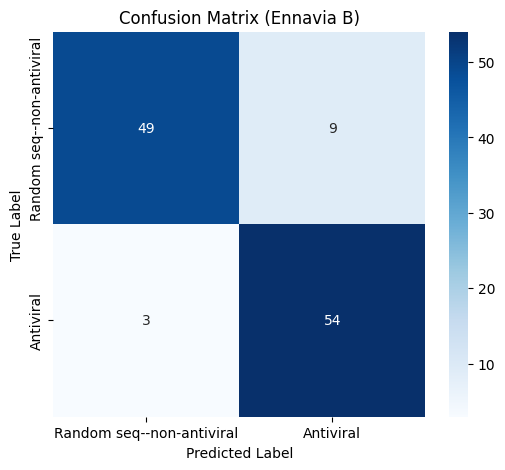


🔹 Classification Report:

                           precision    recall  f1-score   support

Random seq--non-antiviral       0.94      0.84      0.89        58
                Antiviral       0.86      0.95      0.90        57

                 accuracy                           0.90       115
                macro avg       0.90      0.90      0.90       115
             weighted avg       0.90      0.90      0.90       115



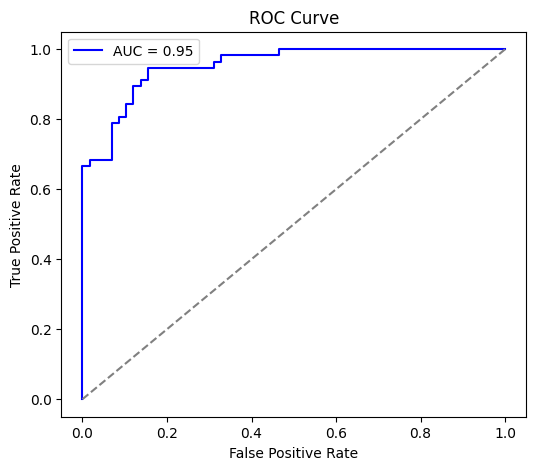

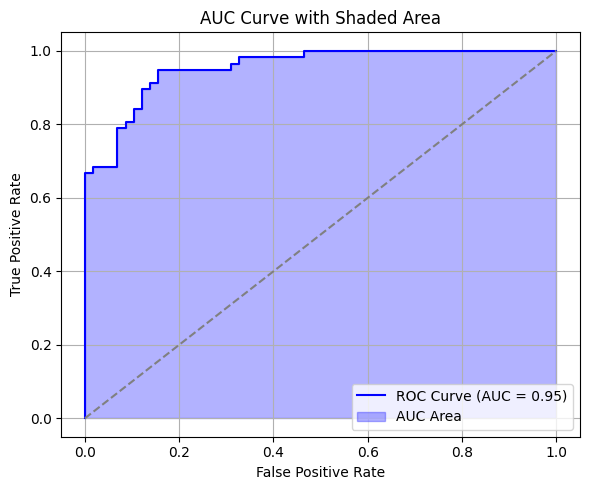

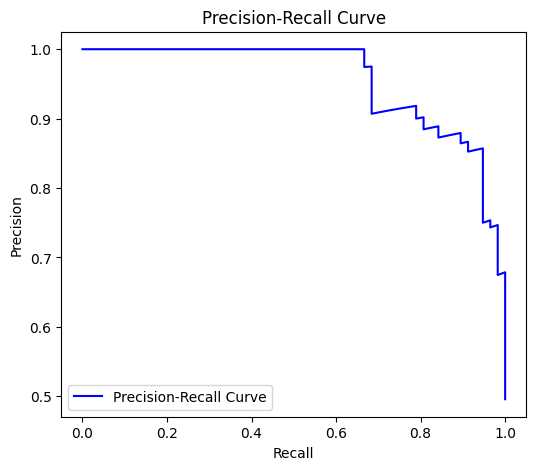

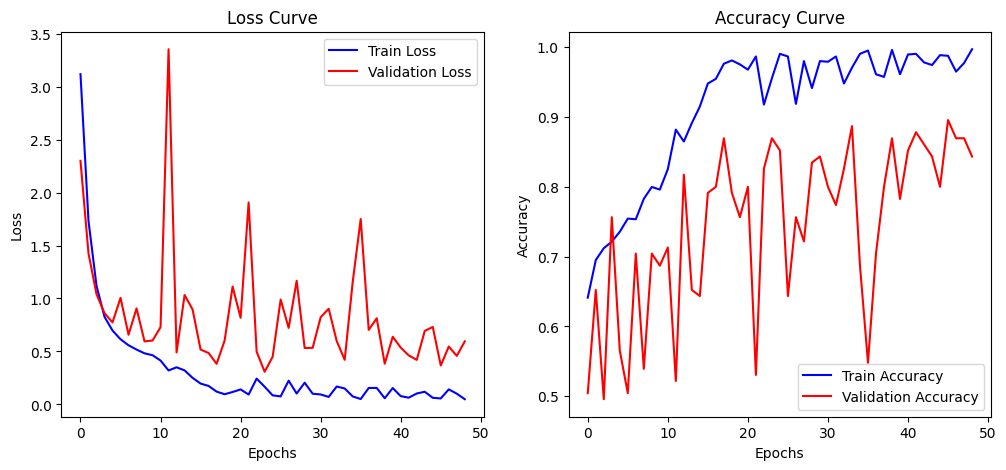

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
4/4 ━━━━━━━━

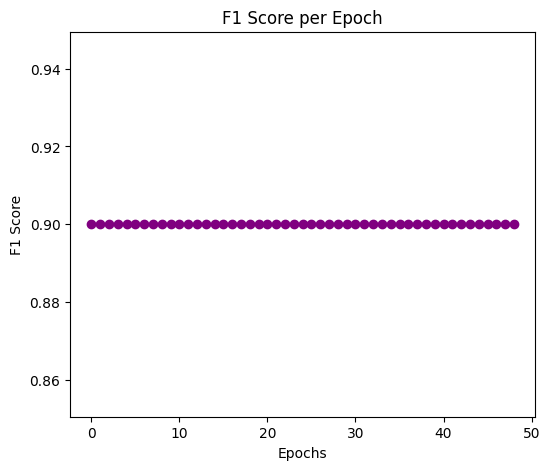

Cohen’s Kappa Score: 0.79
Matthews Correlation Coefficient (MCC): 0.80


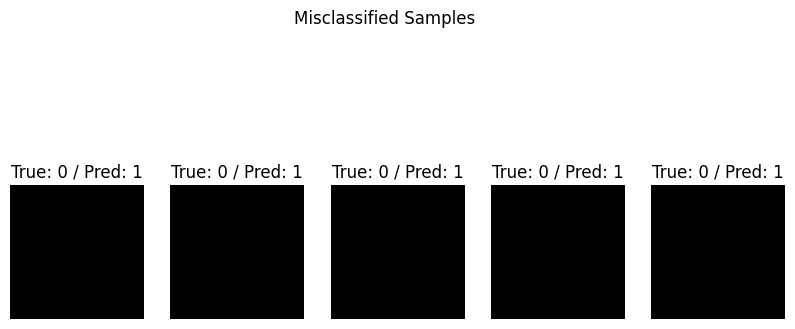


🔟 Performance Metrics Summary Table (For Research Paper)

   Metric  Score
 Accuracy 0.8957
Precision 0.8571
   Recall 0.9474
 F1-score 0.9000
      AUC 0.9537
      MCC 0.7958
   G-mean 0.8946


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_curve, auc,
    precision_recall_curve, f1_score, cohen_kappa_score, matthews_corrcoef,
    accuracy_score, precision_score, recall_score
)
import pandas as pd
import random

# Predict probabilities and binary labels
y_pred_probs = model.predict(X_test)
y_pred = (y_pred_probs > 0.5).astype(int)

# 🔹 1️⃣ Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Random seq--non-antiviral", "Antiviral"],
            yticklabels=["Random seq--non-antiviral", "Antiviral"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (Ennavia B)")
plt.show()

# 🔹 2️⃣ Classification Report
print("\n🔹 Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=["Random seq--non-antiviral", "Antiviral"]))

# 🔹 3️⃣ ROC Curve & AUC Score
fpr, tpr, _ = roc_curve(y_test, y_pred_probs)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='blue', label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

# 🌟 Extra: AUC Curve with Shaded Area
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.fill_between(fpr, tpr, alpha=0.3, color='blue', label='AUC Area')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('AUC Curve with Shaded Area')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

# 🔹 4️⃣ Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_probs)
plt.figure(figsize=(6, 5))
plt.plot(recall, precision, color='blue', label='Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

# 🔹 5️⃣ Training Loss & Accuracy Curves
plt.figure(figsize=(12, 5))

# Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='red')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy Curve')
plt.legend()
plt.show()

# 🔹 6️⃣ F1 Score per Epoch
f1_scores = [f1_score(y_test, (model.predict(X_test) > 0.5).astype(int)) for _ in range(len(history.history['loss']))]
plt.figure(figsize=(6, 5))
plt.plot(f1_scores, color='purple', marker='o')
plt.xlabel('Epochs')
plt.ylabel('F1 Score')
plt.title('F1 Score per Epoch')
plt.show()

# 🔹 7️⃣ Cohen’s Kappa Score
kappa_score = cohen_kappa_score(y_test, y_pred)
print(f"Cohen’s Kappa Score: {kappa_score:.2f}")

# 🔹 8️⃣ Matthews Correlation Coefficient (MCC)
mcc = matthews_corrcoef(y_test, y_pred)
print(f"Matthews Correlation Coefficient (MCC): {mcc:.2f}")

# 🔹 9️⃣ Error Analysis (Misclassified Samples)
misclassified_idx = np.where(y_pred.flatten() != y_test.flatten())[0]
if len(misclassified_idx) > 5:
    misclassified_idx = random.sample(list(misclassified_idx), 5)

plt.figure(figsize=(10, 5))
for i, idx in enumerate(misclassified_idx):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_test[idx].astype("uint8"))
    plt.title(f"True: {y_test[idx]} / Pred: {y_pred[idx][0]}")
    plt.axis("off")
plt.suptitle("Misclassified Samples")
plt.show()

# 🔟 Performance Metrics Summary Table (for Research Paper)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
accuracy = accuracy_score(y_test, y_pred)
precision_val = precision_score(y_test, y_pred)
recall_val = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
sensitivity = recall_val
specificity = tn / (tn + fp)
gmean = np.sqrt(sensitivity * specificity)

performance_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "AUC", "MCC", "G-mean"],
    "Score": [accuracy, precision_val, recall_val, f1, roc_auc, mcc, gmean]
})

print("\n🔟 Performance Metrics Summary Table (For Research Paper)\n")
print(performance_df.round(4).to_string(index=False))


**cnn +CBAM**

In [5]:
import os
import numpy as np
from glob import glob
import cv2
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, regularizers

# Paths to directories (Modify these paths based on your dataset location)
data_dir_train_antiviral = "/kaggle/input/ennavia-b-spectrogram-images-pi-based/spectrogram images/antiviral training images"
data_dir_test_antiviral = "/kaggle/input/ennavia-b-spectrogram-images-pi-based/spectrogram images/antiviral testing images"
,
data_dir_train_non_antiviral = "/kaggle/input/ennavia-b-spectrogram-images-pi-based/spectrogram images/random-seq-non-antiviral training images"
data_dir_test_non_antiviral = "/kaggle/input/ennavia-b-spectrogram-images-pi-based/spectrogram images/random-seq-non-antiviral testing images"


# Image dimensions
IMG_HEIGHT, IMG_WIDTH = 128, 128  

# Function to load and preprocess images
def load_images_from_directory(directory, label):
    images, labels = [], []
    files = glob(os.path.join(directory, "*.png"))  
    for file in files:
        img = cv2.imread(file)
        if img is None:
            continue
        img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))  
        img = img / 255.0  
        images.append(img)
        labels.append(label)  
    return np.array(images), np.array(labels)

# Load training and testing datasets
X_train_antiviral, y_train_antiviral = load_images_from_directory(data_dir_train_antiviral, label=1)
X_test_antiviral, y_test_antiviral = load_images_from_directory(data_dir_test_antiviral, label=1)

X_train_non_antiviral, y_train_non_antiviral = load_images_from_directory(data_dir_train_non_antiviral, label=0)
X_test_non_antiviral, y_test_non_antiviral = load_images_from_directory(data_dir_test_non_antiviral, label=0)

# Combine both classes
X_train = np.concatenate((X_train_antiviral, X_train_non_antiviral), axis=0)
y_train = np.concatenate((y_train_antiviral, y_train_non_antiviral), axis=0)

X_test = np.concatenate((X_test_antiviral, X_test_non_antiviral), axis=0)
y_test = np.concatenate((y_test_antiviral, y_test_non_antiviral), axis=0)

# Shuffle dataset
indices = np.arange(X_train.shape[0])
np.random.shuffle(indices)
X_train, y_train = X_train[indices], y_train[indices]

indices_test = np.arange(X_test.shape[0])
np.random.shuffle(indices_test)
X_test, y_test = X_test[indices_test], y_test[indices_test]

# CBAM Attention Mechanism
def cbam_block(input_tensor, reduction_ratio=16):
    """Convolutional Block Attention Module (CBAM)"""
    filters = input_tensor.shape[-1]

    # Channel Attention
    avg_pool = layers.GlobalAveragePooling2D()(input_tensor)
    max_pool = layers.GlobalMaxPooling2D()(input_tensor)

    shared_dense = layers.Dense(filters // reduction_ratio, activation="relu")
    avg_out = shared_dense(avg_pool)
    max_out = shared_dense(max_pool)

    # 🔹 Correct: Ensure output matches input channels
    shared_dense_2 = layers.Dense(filters, activation="sigmoid")  # Map back to `filters`
    avg_out = shared_dense_2(avg_out)
    max_out = shared_dense_2(max_out)

    avg_out = layers.Reshape((1, 1, filters))(avg_out)
    max_out = layers.Reshape((1, 1, filters))(max_out)

    channel_attention = layers.Add()([avg_out, max_out])
    channel_attention = layers.Activation('sigmoid')(channel_attention)
    
    x = layers.Multiply()([input_tensor, channel_attention])

    # Spatial Attention
    avg_pool = layers.Lambda(lambda x: tf.reduce_mean(x, axis=-1, keepdims=True))(x)
    max_pool = layers.Lambda(lambda x: tf.reduce_max(x, axis=-1, keepdims=True))(x)
    spatial_attention = layers.Concatenate(axis=-1)([avg_pool, max_pool])
    spatial_attention = layers.Conv2D(1, kernel_size=7, padding="same", activation="sigmoid")(spatial_attention)
    
    output_tensor = layers.Multiply()([x, spatial_attention])
    return output_tensor



# Define CNN Model with CBAM
def build_cbam_cnn(input_shape):
    inputs = layers.Input(shape=input_shape)

    # Block 1
    x = layers.Conv2D(32, (5, 5), activation='relu', padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = cbam_block(x)  
    x = layers.MaxPooling2D((2, 2))(x)

    # Block 2
    x = layers.Conv2D(64, (5, 5), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = cbam_block(x)  
    x = layers.MaxPooling2D((2, 2))(x)

    # Block 3 with Residual Connection and CBAM
    res = layers.Conv2D(128, (3, 3), padding='same')(x)
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = cbam_block(x)  
    x = layers.Add()([x, res])  
    x = layers.MaxPooling2D((2, 2))(x)

    # Block 4
    x = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = cbam_block(x)  
    x = layers.MaxPooling2D((2, 2))(x)

    # Global Average Pooling
    x = layers.GlobalAveragePooling2D()(x)

    # Fully Connected Layer
    x = layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.01))(x)
    x = layers.Dropout(0.5)(x)

    # Output Layer
    outputs = layers.Dense(1, activation='sigmoid')(x)

    # Define Model
    model = models.Model(inputs, outputs)

    # Learning Rate Scheduler
    lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate=0.001, decay_steps=5000, decay_rate=0.9, staircase=True
    )
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)

    # Compile Model
    model.compile(optimizer=optimizer, 
                  loss='binary_crossentropy', 
                  metrics=['accuracy'])
    return model

# Instantiate model
model = build_cbam_cnn((IMG_HEIGHT, IMG_WIDTH, 3))

# Callbacks
early_stopping = callbacks.EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True)
model_checkpoint = callbacks.ModelCheckpoint("best_cbam_cnn.keras", monitor='val_accuracy', save_best_only=True)

# Train model
history = model.fit(
    X_train, y_train, batch_size=32, epochs=200,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping, model_checkpoint],
    verbose=1
)

# Load best model and evaluate
model.load_weights("best_cbam_cnn.keras")
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy: {test_accuracy * 100:.2f}%")

# Save model in Kaggle
tf.keras.models.save_model(model, "/kaggle/working/final_cnn+CBAM_model.keras")
print("Model saved successfully in /kaggle/working/")


Epoch 1/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 31s 387ms/step - accuracy: 0.5792 - loss: 3.5626 - val_accuracy: 0.5043 - val_loss: 2.1977
Epoch 2/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.7030 - loss: 1.8298 - val_accuracy: 0.5043 - val_loss: 1.3162
Epoch 3/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.6961 - loss: 1.1060 - val_accuracy: 0.5043 - val_loss: 0.9634
Epoch 4/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.6987 - loss: 0.8159 - val_accuracy: 0.5043 - val_loss: 0.8245
Epoch 5/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.7216 - loss: 0.6743 - val_accuracy: 0.4957 - val_loss: 0.7801
Epoch 6/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.7063 - loss: 0.6313 - val_accuracy: 0.5391 - val_loss: 0.7392
Epoch 7/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.7532 - loss: 0.5575 - val_accuracy: 0.5130 - val_loss: 0.7294
Epoch 8/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.7647 - loss: 0.5153 - val_accuracy: 

4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 627ms/step


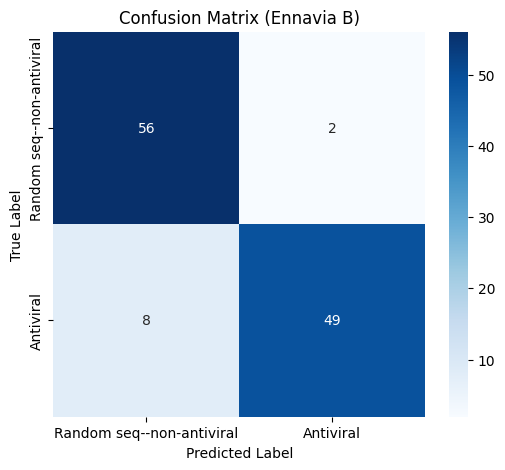


🔹 Classification Report:

                           precision    recall  f1-score   support

Random seq--non-antiviral       0.88      0.97      0.92        58
                Antiviral       0.96      0.86      0.91        57

                 accuracy                           0.91       115
                macro avg       0.92      0.91      0.91       115
             weighted avg       0.92      0.91      0.91       115



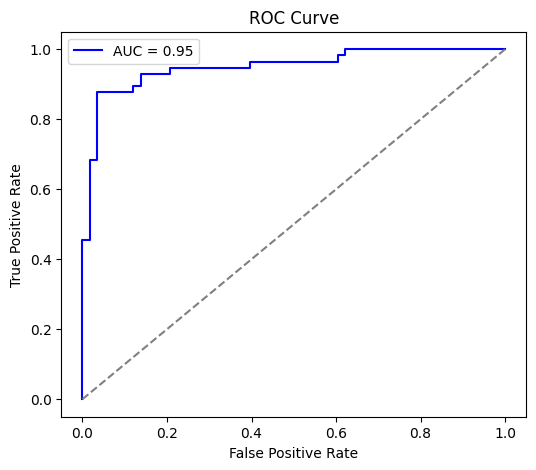

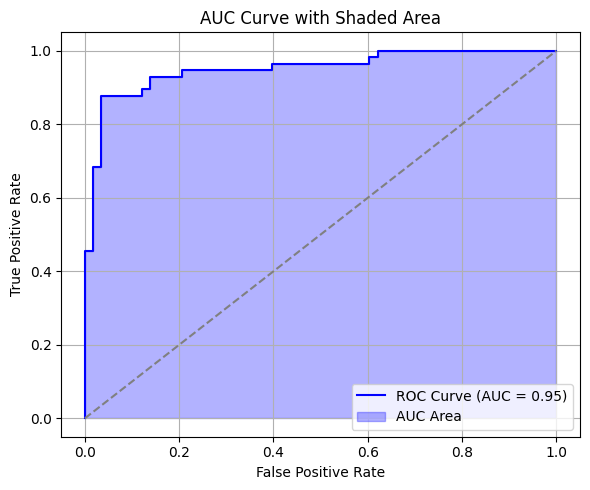

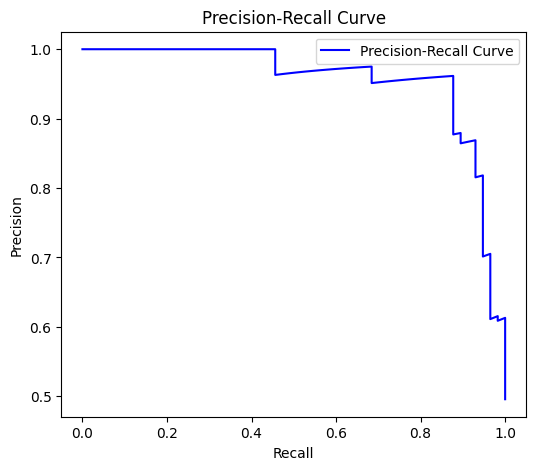

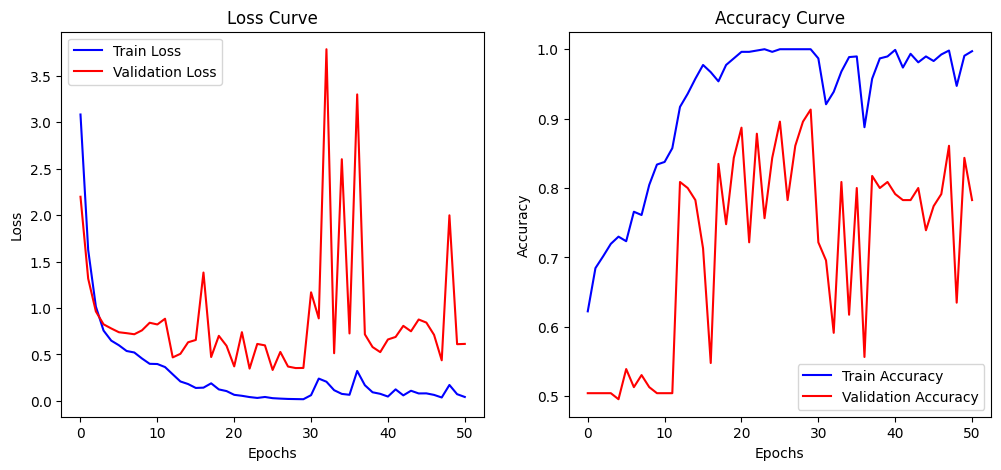

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
4/4 ━━━━━━━━

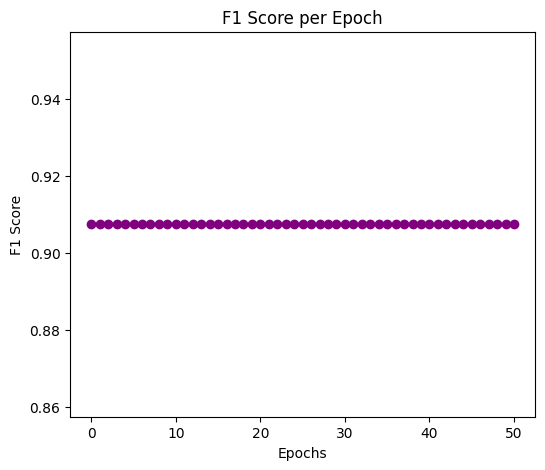

Cohen’s Kappa Score: 0.83
Matthews Correlation Coefficient (MCC): 0.83


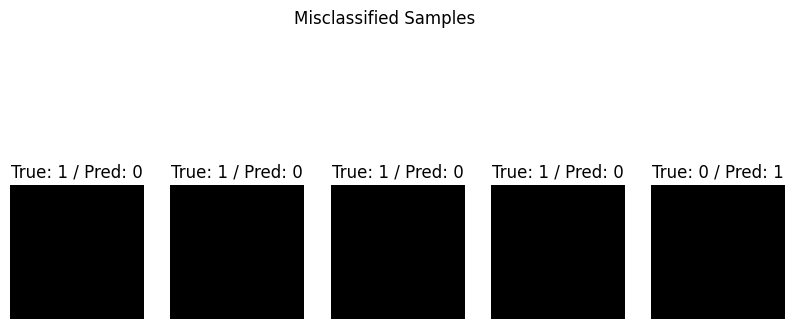


🔟 Performance Metrics Summary Table (For Research Paper)

   Metric  Score
 Accuracy 0.9130
Precision 0.9608
   Recall 0.8596
 F1-score 0.9074
      AUC 0.9504
      MCC 0.8305
   G-mean 0.9110


In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_curve, auc,
    precision_recall_curve, f1_score, cohen_kappa_score, matthews_corrcoef,
    accuracy_score, precision_score, recall_score
)
import pandas as pd
import random

# Predict probabilities and binary labels
y_pred_probs = model.predict(X_test)
y_pred = (y_pred_probs > 0.5).astype(int)

# 🔹 1️⃣ Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Random seq--non-antiviral", "Antiviral"],
            yticklabels=["Random seq--non-antiviral", "Antiviral"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (Ennavia B)")
plt.show()

# 🔹 2️⃣ Classification Report
print("\n🔹 Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=["Random seq--non-antiviral", "Antiviral"]))

# 🔹 3️⃣ ROC Curve & AUC Score
fpr, tpr, _ = roc_curve(y_test, y_pred_probs)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='blue', label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

# 🌟 Extra: AUC Curve with Shaded Area
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.fill_between(fpr, tpr, alpha=0.3, color='blue', label='AUC Area')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('AUC Curve with Shaded Area')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

# 🔹 4️⃣ Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_probs)
plt.figure(figsize=(6, 5))
plt.plot(recall, precision, color='blue', label='Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

# 🔹 5️⃣ Training Loss & Accuracy Curves
plt.figure(figsize=(12, 5))

# Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='red')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy Curve')
plt.legend()
plt.show()

# 🔹 6️⃣ F1 Score per Epoch
f1_scores = [f1_score(y_test, (model.predict(X_test) > 0.5).astype(int)) for _ in range(len(history.history['loss']))]
plt.figure(figsize=(6, 5))
plt.plot(f1_scores, color='purple', marker='o')
plt.xlabel('Epochs')
plt.ylabel('F1 Score')
plt.title('F1 Score per Epoch')
plt.show()

# 🔹 7️⃣ Cohen’s Kappa Score
kappa_score = cohen_kappa_score(y_test, y_pred)
print(f"Cohen’s Kappa Score: {kappa_score:.2f}")

# 🔹 8️⃣ Matthews Correlation Coefficient (MCC)
mcc = matthews_corrcoef(y_test, y_pred)
print(f"Matthews Correlation Coefficient (MCC): {mcc:.2f}")

# 🔹 9️⃣ Error Analysis (Misclassified Samples)
misclassified_idx = np.where(y_pred.flatten() != y_test.flatten())[0]
if len(misclassified_idx) > 5:
    misclassified_idx = random.sample(list(misclassified_idx), 5)

plt.figure(figsize=(10, 5))
for i, idx in enumerate(misclassified_idx):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_test[idx].astype("uint8"))
    plt.title(f"True: {y_test[idx]} / Pred: {y_pred[idx][0]}")
    plt.axis("off")
plt.suptitle("Misclassified Samples")
plt.show()

# 🔟 Performance Metrics Summary Table (for Research Paper)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
accuracy = accuracy_score(y_test, y_pred)
precision_val = precision_score(y_test, y_pred)
recall_val = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
sensitivity = recall_val
specificity = tn / (tn + fp)
gmean = np.sqrt(sensitivity * specificity)

performance_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "AUC", "MCC", "G-mean"],
    "Score": [accuracy, precision_val, recall_val, f1, roc_auc, mcc, gmean]
})

print("\n🔟 Performance Metrics Summary Table (For Research Paper)\n")
print(performance_df.round(4).to_string(index=False))


**resnet50**

In [7]:
import os
import numpy as np
from glob import glob
import cv2
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, applications, regularizers

# Paths to directories (Keep the same dataset paths)
data_dir_train_antiviral = "/kaggle/input/ennavia-b-spectrogram-images-pi-based/spectrogram images/antiviral training images"
data_dir_test_antiviral = "/kaggle/input/ennavia-b-spectrogram-images-pi-based/spectrogram images/antiviral testing images"
,
data_dir_train_non_antiviral = "/kaggle/input/ennavia-b-spectrogram-images-pi-based/spectrogram images/random-seq-non-antiviral training images"
data_dir_test_non_antiviral = "/kaggle/input/ennavia-b-spectrogram-images-pi-based/spectrogram images/random-seq-non-antiviral testing images"


# Image dimensions for ResNet50
IMG_HEIGHT, IMG_WIDTH = 224, 224  

# Function to load and preprocess images
def load_images_from_directory(directory, label):
    images, labels = [], []
    files = glob(os.path.join(directory, "*.png"))  
    for file in files:
        img = cv2.imread(file)
        if img is None:
            continue
        img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))  
        img = img / 255.0  
        images.append(img)
        labels.append(label)  
    return np.array(images), np.array(labels)

# Load training and testing datasets
X_train_antiviral, y_train_antiviral = load_images_from_directory(data_dir_train_antiviral, label=1)
X_test_antiviral, y_test_antiviral = load_images_from_directory(data_dir_test_antiviral, label=1)

X_train_non_antiviral, y_train_non_antiviral = load_images_from_directory(data_dir_train_non_antiviral, label=0)
X_test_non_antiviral, y_test_non_antiviral = load_images_from_directory(data_dir_test_non_antiviral, label=0)

# Combine both classes
X_train = np.concatenate((X_train_antiviral, X_train_non_antiviral), axis=0)
y_train = np.concatenate((y_train_antiviral, y_train_non_antiviral), axis=0)

X_test = np.concatenate((X_test_antiviral, X_test_non_antiviral), axis=0)
y_test = np.concatenate((y_test_antiviral, y_test_non_antiviral), axis=0)

# Shuffle dataset
indices = np.arange(X_train.shape[0])
np.random.shuffle(indices)
X_train, y_train = X_train[indices], y_train[indices]

indices_test = np.arange(X_test.shape[0])
np.random.shuffle(indices_test)
X_test, y_test = X_test[indices_test], y_test[indices_test]

# Build ResNet50 Model (Without SE Attention)
def build_resnet_model(input_shape):
    base_model = applications.ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)

    # Freeze initial layers, fine-tune last layers
    for layer in base_model.layers[:140]:  
        layer.trainable = False

    inputs = layers.Input(shape=input_shape)
    x = base_model(inputs, training=False)

    # Global Pooling & Dense Layers
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.01))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)  

    model = models.Model(inputs, outputs)

    lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate=0.0001, decay_steps=5000, decay_rate=0.9, staircase=True
    )
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)
    
    model.compile(optimizer=optimizer, 
                  loss='binary_crossentropy', 
                  metrics=['accuracy'])
    return model

# Instantiate ResNet Model
model = build_resnet_model((IMG_HEIGHT, IMG_WIDTH, 3))

# Callbacks
early_stopping = callbacks.EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True)
model_checkpoint = callbacks.ModelCheckpoint("best_resnet_model.keras", monitor='val_accuracy', save_best_only=True)

# Train Model
history = model.fit(
    X_train, y_train, batch_size=32, epochs=200,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping, model_checkpoint],
    verbose=1
)

# Load best model and evaluate
model.load_weights("best_resnet_model.keras")
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy: {test_accuracy * 100:.2f}%")

# Save model in Kaggle
tf.keras.models.save_model(model, "/kaggle/working/final_resnet50_model.keras")
print("Model saved successfully in /kaggle/working/")



94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 51s 650ms/step - accuracy: 0.6332 - loss: 5.3187 - val_accuracy: 0.4696 - val_loss: 5.0249
Epoch 2/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 6s 189ms/step - accuracy: 0.7125 - loss: 4.8433 - val_accuracy: 0.4957 - val_loss: 4.8887
Epoch 3/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 147ms/step - accuracy: 0.7509 - loss: 4.6051 - val_accuracy: 0.4957 - val_loss: 4.8862
Epoch 4/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 148ms/step - accuracy: 0.7725 - loss: 4.3439 - val_accuracy: 0.4957 - val_loss: 4.8651
Epoch 5/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 145ms/step - accuracy: 0.8297 - loss: 4.0716 - val_accuracy: 0.4957 - val_loss: 4.8782
Epoch 6/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 149ms/step - accuracy: 0.8150 - loss: 3.9297 - val_accuracy: 0.4957 - val_loss: 4.8547
Epoch 7/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 6s 191ms/step - accuracy: 0.8320 - loss: 3.7149 - val_accuracy: 0.6435 - val_loss: 4.2234
Epoch 8/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 6s 191

4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step 


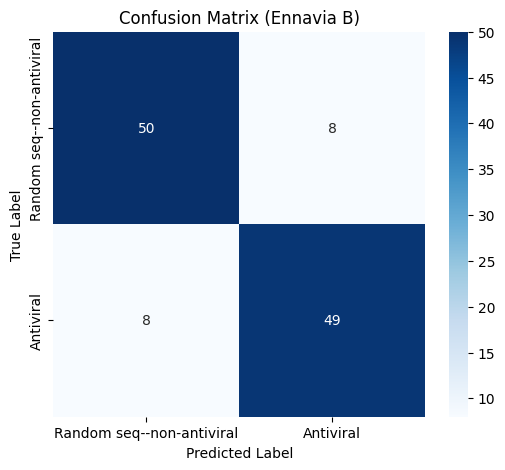


🔹 Classification Report:

                           precision    recall  f1-score   support

Random seq--non-antiviral       0.86      0.86      0.86        58
                Antiviral       0.86      0.86      0.86        57

                 accuracy                           0.86       115
                macro avg       0.86      0.86      0.86       115
             weighted avg       0.86      0.86      0.86       115



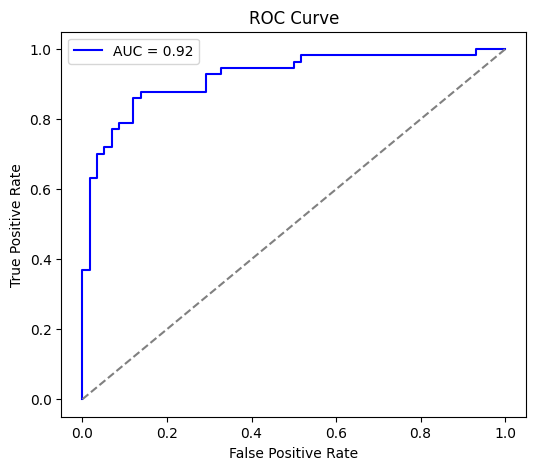

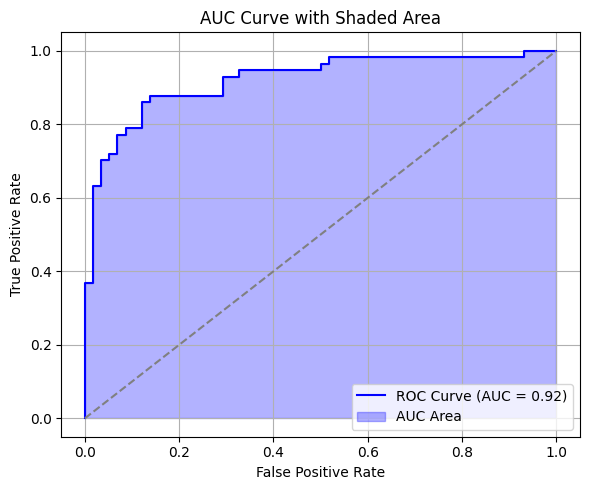

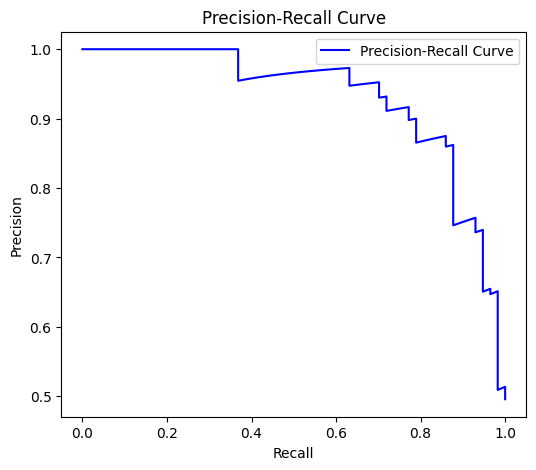

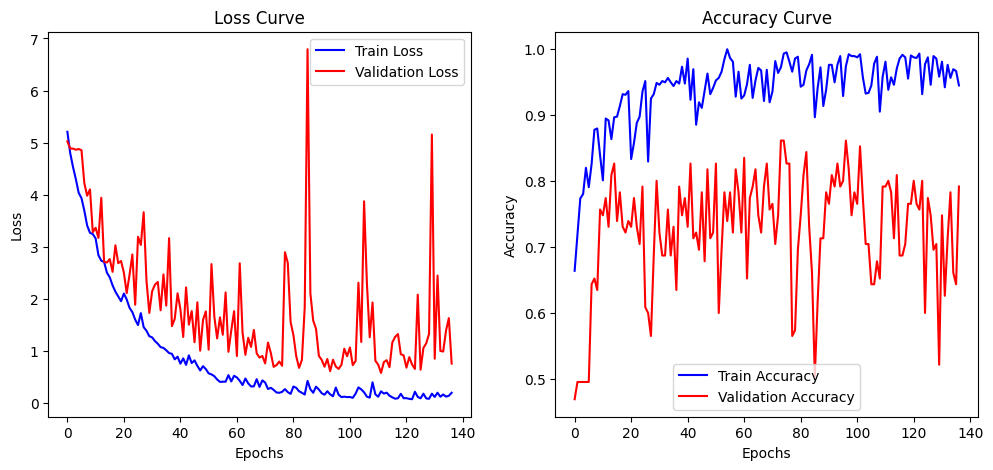

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
4/4 ━━━━━━━━

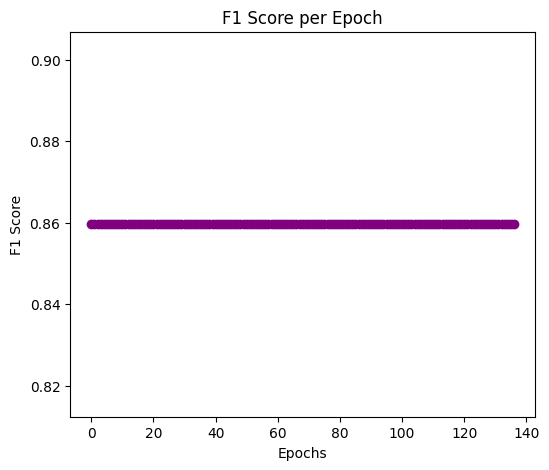

Cohen’s Kappa Score: 0.72
Matthews Correlation Coefficient (MCC): 0.72


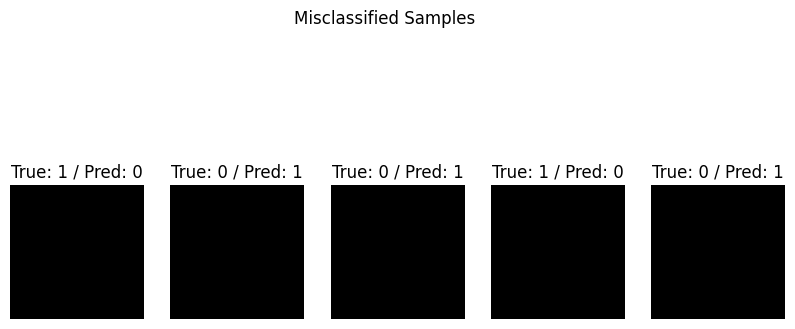


🔟 Performance Metrics Summary Table (For Research Paper)

   Metric  Score
 Accuracy 0.8609
Precision 0.8596
   Recall 0.8596
 F1-score 0.8596
      AUC 0.9208
      MCC 0.7217
   G-mean 0.8609


In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_curve, auc,
    precision_recall_curve, f1_score, cohen_kappa_score, matthews_corrcoef,
    accuracy_score, precision_score, recall_score
)
import pandas as pd
import random

# Predict probabilities and binary labels
y_pred_probs = model.predict(X_test)
y_pred = (y_pred_probs > 0.5).astype(int)

# 🔹 1️⃣ Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Random seq--non-antiviral", "Antiviral"],
            yticklabels=["Random seq--non-antiviral", "Antiviral"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (Ennavia B)")
plt.show()

# 🔹 2️⃣ Classification Report
print("\n🔹 Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=["Random seq--non-antiviral", "Antiviral"]))

# 🔹 3️⃣ ROC Curve & AUC Score
fpr, tpr, _ = roc_curve(y_test, y_pred_probs)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='blue', label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

# 🌟 Extra: AUC Curve with Shaded Area
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.fill_between(fpr, tpr, alpha=0.3, color='blue', label='AUC Area')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('AUC Curve with Shaded Area')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

# 🔹 4️⃣ Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_probs)
plt.figure(figsize=(6, 5))
plt.plot(recall, precision, color='blue', label='Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

# 🔹 5️⃣ Training Loss & Accuracy Curves
plt.figure(figsize=(12, 5))

# Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='red')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy Curve')
plt.legend()
plt.show()

# 🔹 6️⃣ F1 Score per Epoch
f1_scores = [f1_score(y_test, (model.predict(X_test) > 0.5).astype(int)) for _ in range(len(history.history['loss']))]
plt.figure(figsize=(6, 5))
plt.plot(f1_scores, color='purple', marker='o')
plt.xlabel('Epochs')
plt.ylabel('F1 Score')
plt.title('F1 Score per Epoch')
plt.show()

# 🔹 7️⃣ Cohen’s Kappa Score
kappa_score = cohen_kappa_score(y_test, y_pred)
print(f"Cohen’s Kappa Score: {kappa_score:.2f}")

# 🔹 8️⃣ Matthews Correlation Coefficient (MCC)
mcc = matthews_corrcoef(y_test, y_pred)
print(f"Matthews Correlation Coefficient (MCC): {mcc:.2f}")

# 🔹 9️⃣ Error Analysis (Misclassified Samples)
misclassified_idx = np.where(y_pred.flatten() != y_test.flatten())[0]
if len(misclassified_idx) > 5:
    misclassified_idx = random.sample(list(misclassified_idx), 5)

plt.figure(figsize=(10, 5))
for i, idx in enumerate(misclassified_idx):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_test[idx].astype("uint8"))
    plt.title(f"True: {y_test[idx]} / Pred: {y_pred[idx][0]}")
    plt.axis("off")
plt.suptitle("Misclassified Samples")
plt.show()

# 🔟 Performance Metrics Summary Table (for Research Paper)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
accuracy = accuracy_score(y_test, y_pred)
precision_val = precision_score(y_test, y_pred)
recall_val = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
sensitivity = recall_val
specificity = tn / (tn + fp)
gmean = np.sqrt(sensitivity * specificity)

performance_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "AUC", "MCC", "G-mean"],
    "Score": [accuracy, precision_val, recall_val, f1, roc_auc, mcc, gmean]
})

print("\n🔟 Performance Metrics Summary Table (For Research Paper)\n")
print(performance_df.round(4).to_string(index=False))


**resnet 50 + SE**

In [9]:
import os
import numpy as np
from glob import glob
import cv2
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, applications, regularizers

# Paths to directories (Keep the same dataset paths)
data_dir_train_antiviral = "/kaggle/input/ennavia-b-spectrogram-images-pi-based/spectrogram images/antiviral training images"
data_dir_test_antiviral = "/kaggle/input/ennavia-b-spectrogram-images-pi-based/spectrogram images/antiviral testing images"
,
data_dir_train_non_antiviral = "/kaggle/input/ennavia-b-spectrogram-images-pi-based/spectrogram images/random-seq-non-antiviral training images"
data_dir_test_non_antiviral = "/kaggle/input/ennavia-b-spectrogram-images-pi-based/spectrogram images/random-seq-non-antiviral testing images"


# Image dimensions for ResNet50
IMG_HEIGHT, IMG_WIDTH = 224, 224  

# Function to load and preprocess images
def load_images_from_directory(directory, label):
    images, labels = [], []
    files = glob(os.path.join(directory, "*.png"))  
    for file in files:
        img = cv2.imread(file)
        if img is None:
            continue
        img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))  
        img = img / 255.0  
        images.append(img)
        labels.append(label)  
    return np.array(images), np.array(labels)

# Load training and testing datasets
X_train_antiviral, y_train_antiviral = load_images_from_directory(data_dir_train_antiviral, label=1)
X_test_antiviral, y_test_antiviral = load_images_from_directory(data_dir_test_antiviral, label=1)

X_train_non_antiviral, y_train_non_antiviral = load_images_from_directory(data_dir_train_non_antiviral, label=0)
X_test_non_antiviral, y_test_non_antiviral = load_images_from_directory(data_dir_test_non_antiviral, label=0)

# Combine both classes
X_train = np.concatenate((X_train_antiviral, X_train_non_antiviral), axis=0)
y_train = np.concatenate((y_train_antiviral, y_train_non_antiviral), axis=0)

X_test = np.concatenate((X_test_antiviral, X_test_non_antiviral), axis=0)
y_test = np.concatenate((y_test_antiviral, y_test_non_antiviral), axis=0)

# Shuffle dataset
indices = np.arange(X_train.shape[0])
np.random.shuffle(indices)
X_train, y_train = X_train[indices], y_train[indices]

indices_test = np.arange(X_test.shape[0])
np.random.shuffle(indices_test)
X_test, y_test = X_test[indices_test], y_test[indices_test]

# Squeeze and Excitation Block
def squeeze_excite_block(input_tensor, ratio=16):
    filters = input_tensor.shape[-1]  
    se = layers.GlobalAveragePooling2D()(input_tensor)  
    se = layers.Dense(filters // ratio, activation='relu')(se)  
    se = layers.Dense(filters, activation='sigmoid')(se)  
    se = layers.Reshape((1, 1, filters))(se)  
    return layers.Multiply()([input_tensor, se])  

# Build ResNet50 Model with SE Attention
def build_resnet_model(input_shape):
    base_model = applications.ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)

    # Freeze the lower ResNet layers
    for layer in base_model.layers[:140]:  # Fine-tune last layers
        layer.trainable = False

    inputs = layers.Input(shape=input_shape)
    x = base_model(inputs, training=False)

    # SE Attention Block
    x = squeeze_excite_block(x)

    # Global Pooling & Dense Layers
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.01))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)  

    model = models.Model(inputs, outputs)

    lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate=0.0001, decay_steps=5000, decay_rate=0.9, staircase=True
    )
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)
    
    model.compile(optimizer=optimizer, 
                  loss='binary_crossentropy', 
                  metrics=['accuracy'])
    return model

# Instantiate ResNet Model
model = build_resnet_model((IMG_HEIGHT, IMG_WIDTH, 3))

# Callbacks
early_stopping = callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
model_checkpoint = callbacks.ModelCheckpoint("best_resnet_model.keras", monitor='val_accuracy', save_best_only=True)

# Train Model
history = model.fit(
    X_train, y_train, batch_size=32, epochs=200,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping, model_checkpoint],
    verbose=1
)

# Load best model and evaluate
model.load_weights("best_resnet_model.keras")
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy: {test_accuracy * 100:.2f}%")

# Save model in Kaggle
tf.keras.models.save_model(model, "/kaggle/working/final_resnet50+SE_model.keras")
print("Model saved successfully in /kaggle/working/")



Epoch 1/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 45s 574ms/step - accuracy: 0.6675 - loss: 5.1704 - val_accuracy: 0.5043 - val_loss: 5.0166
Epoch 2/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 149ms/step - accuracy: 0.7580 - loss: 4.7831 - val_accuracy: 0.5043 - val_loss: 4.7506
Epoch 3/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 7s 193ms/step - accuracy: 0.7722 - loss: 4.4797 - val_accuracy: 0.5217 - val_loss: 4.4978
Epoch 4/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 153ms/step - accuracy: 0.8118 - loss: 4.1666 - val_accuracy: 0.4957 - val_loss: 4.3252
Epoch 5/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 154ms/step - accuracy: 0.8187 - loss: 3.9159 - val_accuracy: 0.4957 - val_loss: 4.2251
Epoch 6/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 154ms/step - accuracy: 0.8349 - loss: 3.7124 - val_accuracy: 0.5043 - val_loss: 3.9075
Epoch 7/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 7s 195ms/step - accuracy: 0.8315 - loss: 3.5219 - val_accuracy: 0.6435 - val_loss: 3.7027
Epoch 8/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 146ms/step - accuracy: 0.8522 - loss: 3.3007 - val_acc

4/4 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step


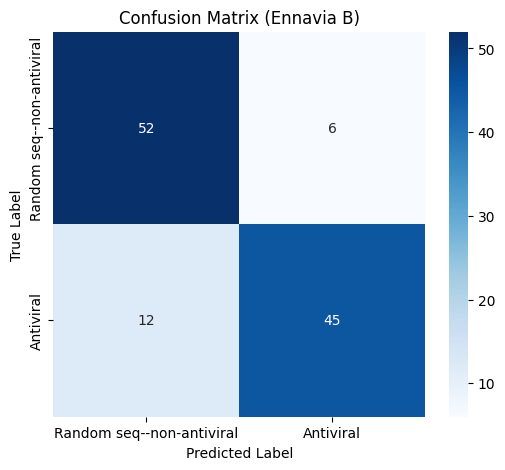


🔹 Classification Report:

                           precision    recall  f1-score   support

Random seq--non-antiviral       0.81      0.90      0.85        58
                Antiviral       0.88      0.79      0.83        57

                 accuracy                           0.84       115
                macro avg       0.85      0.84      0.84       115
             weighted avg       0.85      0.84      0.84       115



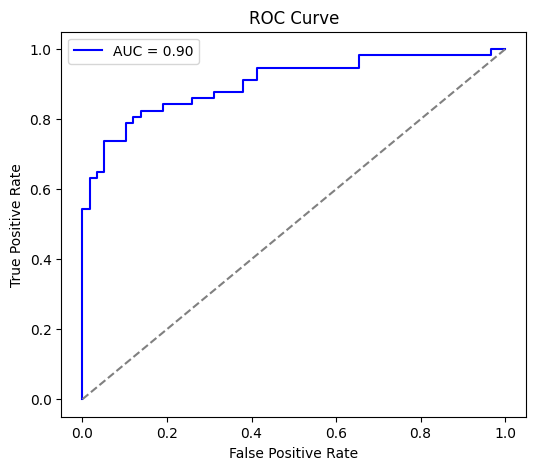

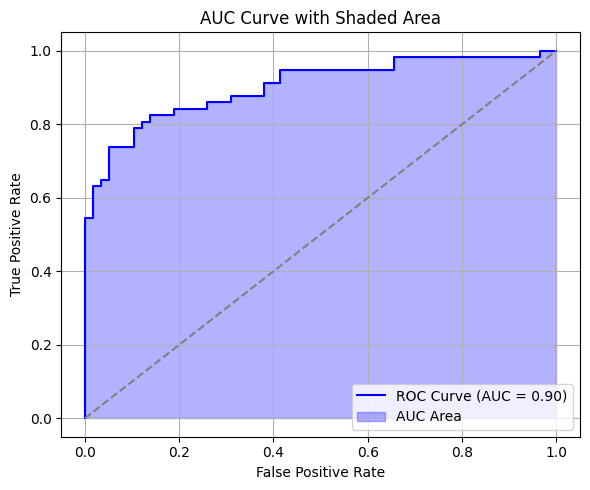

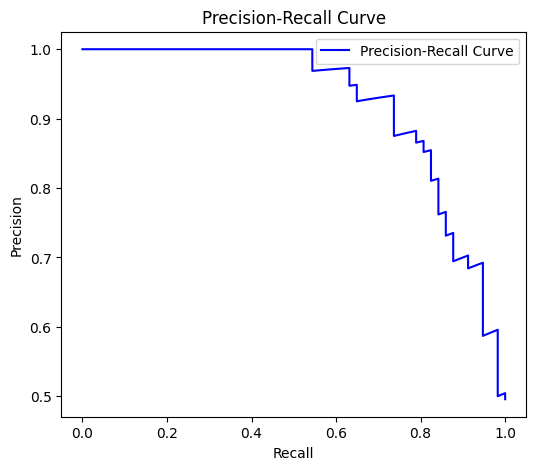

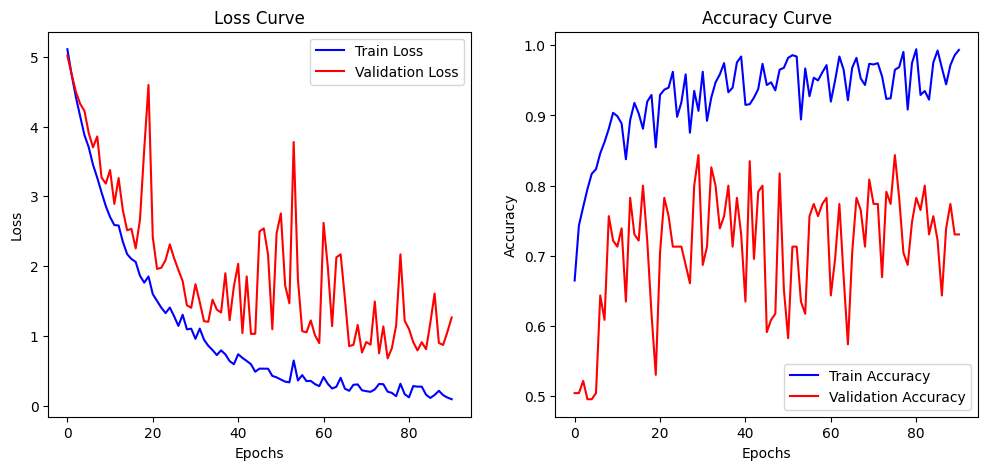

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
4/4 ━━━━━━━━

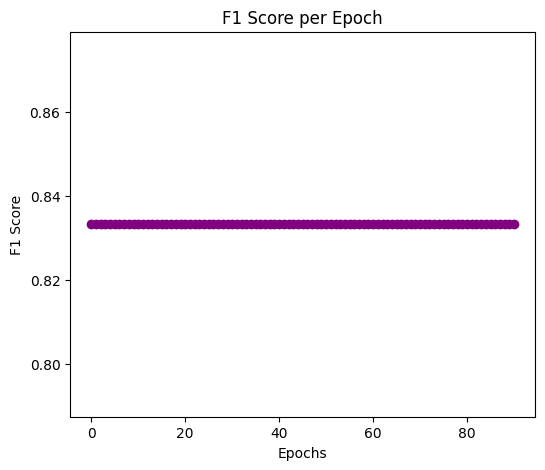

Cohen’s Kappa Score: 0.69
Matthews Correlation Coefficient (MCC): 0.69


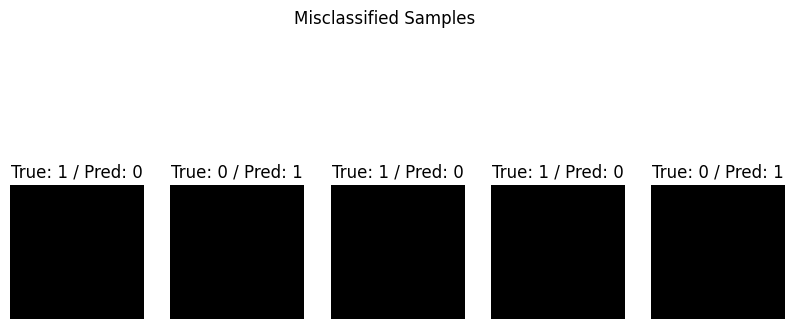


🔟 Performance Metrics Summary Table (For Research Paper)

   Metric  Score
 Accuracy 0.8435
Precision 0.8824
   Recall 0.7895
 F1-score 0.8333
      AUC 0.9023
      MCC 0.6904
   G-mean 0.8413


In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_curve, auc,
    precision_recall_curve, f1_score, cohen_kappa_score, matthews_corrcoef,
    accuracy_score, precision_score, recall_score
)
import pandas as pd
import random

# Predict probabilities and binary labels
y_pred_probs = model.predict(X_test)
y_pred = (y_pred_probs > 0.5).astype(int)

# 🔹 1️⃣ Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Random seq--non-antiviral", "Antiviral"],
            yticklabels=["Random seq--non-antiviral", "Antiviral"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (Ennavia B)")
plt.show()

# 🔹 2️⃣ Classification Report
print("\n🔹 Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=["Random seq--non-antiviral", "Antiviral"]))

# 🔹 3️⃣ ROC Curve & AUC Score
fpr, tpr, _ = roc_curve(y_test, y_pred_probs)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='blue', label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

# 🌟 Extra: AUC Curve with Shaded Area
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.fill_between(fpr, tpr, alpha=0.3, color='blue', label='AUC Area')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('AUC Curve with Shaded Area')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

# 🔹 4️⃣ Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_probs)
plt.figure(figsize=(6, 5))
plt.plot(recall, precision, color='blue', label='Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

# 🔹 5️⃣ Training Loss & Accuracy Curves
plt.figure(figsize=(12, 5))

# Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='red')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy Curve')
plt.legend()
plt.show()

# 🔹 6️⃣ F1 Score per Epoch
f1_scores = [f1_score(y_test, (model.predict(X_test) > 0.5).astype(int)) for _ in range(len(history.history['loss']))]
plt.figure(figsize=(6, 5))
plt.plot(f1_scores, color='purple', marker='o')
plt.xlabel('Epochs')
plt.ylabel('F1 Score')
plt.title('F1 Score per Epoch')
plt.show()

# 🔹 7️⃣ Cohen’s Kappa Score
kappa_score = cohen_kappa_score(y_test, y_pred)
print(f"Cohen’s Kappa Score: {kappa_score:.2f}")

# 🔹 8️⃣ Matthews Correlation Coefficient (MCC)
mcc = matthews_corrcoef(y_test, y_pred)
print(f"Matthews Correlation Coefficient (MCC): {mcc:.2f}")

# 🔹 9️⃣ Error Analysis (Misclassified Samples)
misclassified_idx = np.where(y_pred.flatten() != y_test.flatten())[0]
if len(misclassified_idx) > 5:
    misclassified_idx = random.sample(list(misclassified_idx), 5)

plt.figure(figsize=(10, 5))
for i, idx in enumerate(misclassified_idx):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_test[idx].astype("uint8"))
    plt.title(f"True: {y_test[idx]} / Pred: {y_pred[idx][0]}")
    plt.axis("off")
plt.suptitle("Misclassified Samples")
plt.show()

# 🔟 Performance Metrics Summary Table (for Research Paper)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
accuracy = accuracy_score(y_test, y_pred)
precision_val = precision_score(y_test, y_pred)
recall_val = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
sensitivity = recall_val
specificity = tn / (tn + fp)
gmean = np.sqrt(sensitivity * specificity)

performance_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "AUC", "MCC", "G-mean"],
    "Score": [accuracy, precision_val, recall_val, f1, roc_auc, mcc, gmean]
})

print("\n🔟 Performance Metrics Summary Table (For Research Paper)\n")
print(performance_df.round(4).to_string(index=False))


**resnet50 + CBAM**

In [11]:
import os
import numpy as npa
from glob import glob
import cv2
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import layers, models, callbacks, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet import preprocess_input
from tensorflow.keras.layers import (
    GlobalAveragePooling2D, GlobalMaxPooling2D, Dense, Reshape, Multiply,
    Conv2D, Add, Activation, Lambda, Dropout
)
from tensorflow.keras import backend as K

# Paths to directories (Modify these paths based on your dataset location)
data_dir_train_antiviral = "/kaggle/input/ennavia-b-spectrogram-images-pi-based/spectrogram images/antiviral training images"
data_dir_test_antiviral = "/kaggle/input/ennavia-b-spectrogram-images-pi-based/spectrogram images/antiviral testing images"
,
data_dir_train_non_antiviral = "/kaggle/input/ennavia-b-spectrogram-images-pi-based/spectrogram images/random-seq-non-antiviral training images"
data_dir_test_non_antiviral = "/kaggle/input/ennavia-b-spectrogram-images-pi-based/spectrogram images/random-seq-non-antiviral testing images"



# Image dimensions and parameters
IMG_HEIGHT, IMG_WIDTH = 224, 224  # ResNet50 expects 224x224 images

# Function to load and preprocess images for a given class
def load_images_from_directory(directory, label):
    images, labels = [], []
    files = glob(os.path.join(directory, "*.png"))  # Assumes images are in PNG format
    for file in files:
        img = cv2.imread(file)
        if img is None:
            continue
        img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))  # Resize to ResNet input size
        img = preprocess_input(img)  # Normalize using ResNet's preprocess function
        images.append(img)
        labels.append(label)  # Assign the given label (0 or 1)
    return np.array(images), np.array(labels)

# Load training and testing datasets for both classes
X_train_antiviral, y_train_antiviral = load_images_from_directory(data_dir_train_antiviral, label=1)
X_test_antiviral, y_test_antiviral = load_images_from_directory(data_dir_test_antiviral, label=1)

X_train_non_antiviral, y_train_non_antiviral = load_images_from_directory(data_dir_train_non_antiviral, label=0)
X_test_non_antiviral, y_test_non_antiviral = load_images_from_directory(data_dir_test_non_antiviral, label=0)

# Combine both classes into a single dataset
X_train = np.concatenate((X_train_antiviral, X_train_non_antiviral), axis=0)
y_train = np.concatenate((y_train_antiviral, y_train_non_antiviral), axis=0)

X_test = np.concatenate((X_test_antiviral, X_test_non_antiviral), axis=0)
y_test = np.concatenate((y_test_antiviral, y_test_non_antiviral), axis=0)

# Shuffle dataset to avoid order bias
indices = np.arange(X_train.shape[0])
np.random.shuffle(indices)
X_train, y_train = X_train[indices], y_train[indices]

indices_test = np.arange(X_test.shape[0])
np.random.shuffle(indices_test)
X_test, y_test = X_test[indices_test], y_test[indices_test]

# Data Augmentation
datagen = ImageDataGenerator(
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.8, 1.2],
)

# CBAM Attention Mechanism
def cbam_block(input_tensor, ratio=8):
    """Convolutional Block Attention Module (CBAM)"""
    
    # 🔹 Channel Attention
    channel_avg = GlobalAveragePooling2D()(input_tensor)
    channel_max = GlobalMaxPooling2D()(input_tensor)
    
    channel_avg = Dense(input_tensor.shape[-1] // ratio, activation='relu')(channel_avg)
    channel_avg = Dense(input_tensor.shape[-1], activation='sigmoid')(channel_avg)
    
    channel_max = Dense(input_tensor.shape[-1] // ratio, activation='relu')(channel_max)
    channel_max = Dense(input_tensor.shape[-1], activation='sigmoid')(channel_max)
    
    channel_att = Add()([channel_avg, channel_max])
    channel_att = Activation('sigmoid')(channel_att)
    channel_att = Reshape((1, 1, input_tensor.shape[-1]))(channel_att)
    channel_refined = Multiply()([input_tensor, channel_att])

    # 🔹 Spatial Attention
    avg_pool = Lambda(lambda x: tf.reduce_mean(x, axis=-1, keepdims=True))(channel_refined)
    max_pool = Lambda(lambda x: tf.reduce_max(x, axis=-1, keepdims=True))(channel_refined)
    
    spatial_att = Conv2D(1, kernel_size=7, padding='same', activation='sigmoid')(Add()([avg_pool, max_pool]))
    spatial_refined = Multiply()([channel_refined, spatial_att])

    return spatial_refined

# Define ResNet50-based Model with CBAM
def build_resnet_cbam_model(input_shape):
    # Load pretrained ResNet50 model (excluding the top classification layer)
    base_model = ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)

    # Freeze initial layers (up to conv4_block6, modify as needed for fine-tuning)
    for layer in base_model.layers[:143]:  # Freezes earlier layers
        layer.trainable = False
    for layer in base_model.layers[143:]:  # Fine-tune last few layers
        layer.trainable = True

    # Apply CBAM Attention
    x = cbam_block(base_model.output)

    # Custom classification head
    x = GlobalAveragePooling2D()(x)
    x = Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.01))(x)
    x = Dropout(0.5)(x)
    outputs = Dense(1, activation='sigmoid')(x)  # Binary classification

    # Build and compile the model
    model = models.Model(inputs=base_model.input, outputs=outputs)

    # Compile model with Adam optimizer and adaptive learning rate
    initial_learning_rate = 0.0001
    lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate, decay_steps=10000, decay_rate=0.9, staircase=True)
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)
    
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Instantiate model with CBAM
model = build_resnet_cbam_model((IMG_HEIGHT, IMG_WIDTH, 3))

# Callbacks for early stopping and model checkpointing
early_stopping = callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
model_checkpoint = callbacks.ModelCheckpoint("best_resnet_cbam_model.keras", monitor='val_accuracy', save_best_only=True)

# Train model
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    epochs=200,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping, model_checkpoint],
    verbose=1
)

# Load best model and evaluate
model.load_weights("best_resnet_cbam_model.keras")
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy with CBAM: {test_accuracy * 100:.2f}%")

# Save model in Kaggle
tf.keras.models.save_model(model, "/kaggle/working/final_resnet50+CBAM_model.keras")
print("Model saved successfully in /kaggle/working/")



/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 46s 600ms/step - accuracy: 0.5864 - loss: 8.6190 - val_accuracy: 0.5913 - val_loss: 7.9350
Epoch 2/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 146ms/step - accuracy: 0.7752 - loss: 7.5168 - val_accuracy: 0.5739 - val_loss: 7.1161
Epoch 3/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 7s 193ms/step - accuracy: 0.8198 - loss: 6.6561 - val_accuracy: 0.6870 - val_loss: 6.2690
Epoch 4/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 152ms/step - accuracy: 0.8675 - loss: 5.8519 - val_accuracy: 0.6696 - val_loss: 5.6128
Epoch 5/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 7s 197ms/step - accuracy: 0.8825 - loss: 5.1866 - val_accuracy: 0.7826 - val_loss: 4.9675
Epoch 6/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 150ms/step - accuracy: 0.8993 - loss: 4.5868 - val_accuracy: 0.7739 - val_loss: 4.4863
Epoch 7/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 7s 194ms/step - accuracy: 0.9009 - loss: 4.0523 - val_accuracy: 0.8348 - val_loss: 4.0265
Epoch 8/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 147ms/step - accuracy: 0.8800 - loss: 3.6356 - val_acc

4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step  


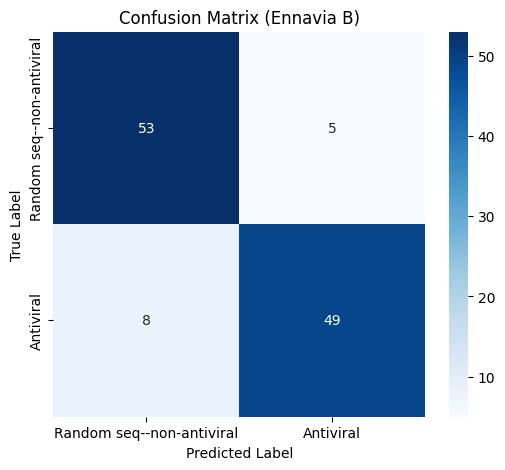


🔹 Classification Report:

                           precision    recall  f1-score   support

Random seq--non-antiviral       0.87      0.91      0.89        58
                Antiviral       0.91      0.86      0.88        57

                 accuracy                           0.89       115
                macro avg       0.89      0.89      0.89       115
             weighted avg       0.89      0.89      0.89       115



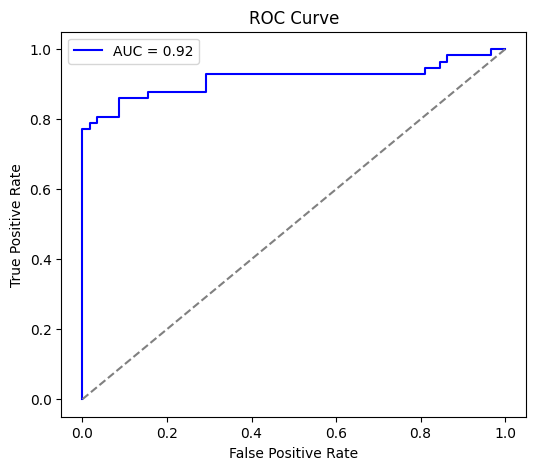

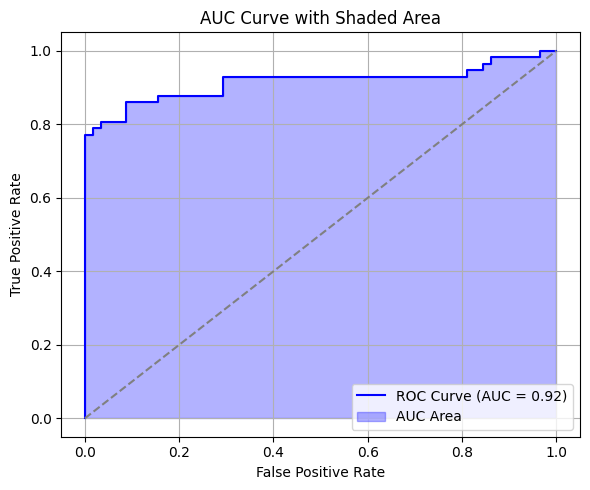

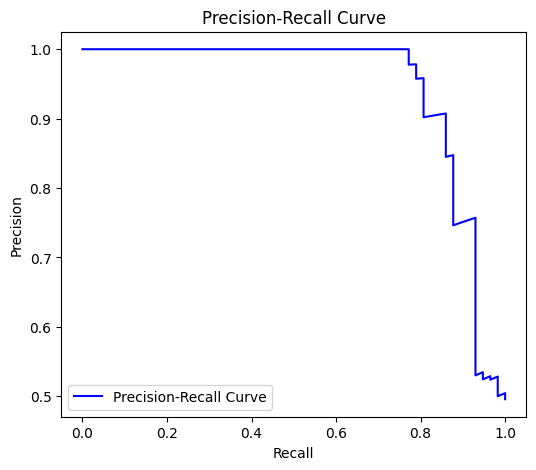

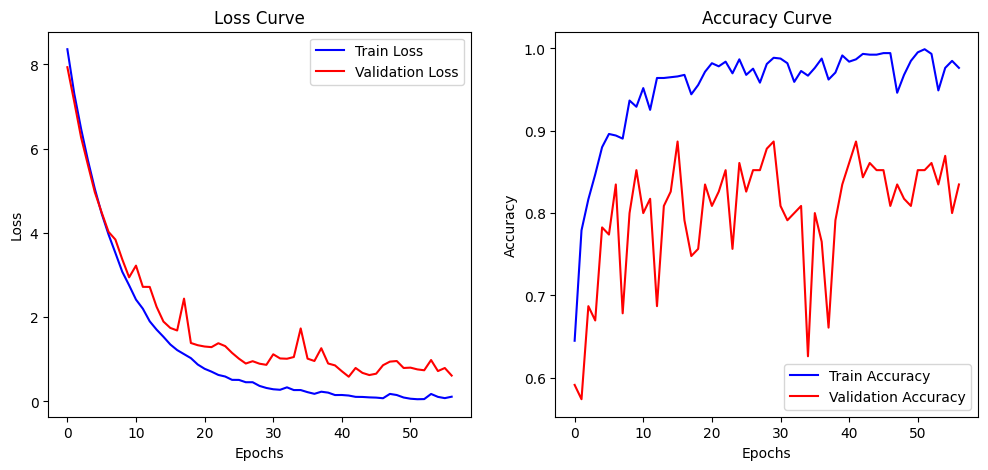

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
4/4 ━━━━━━━━

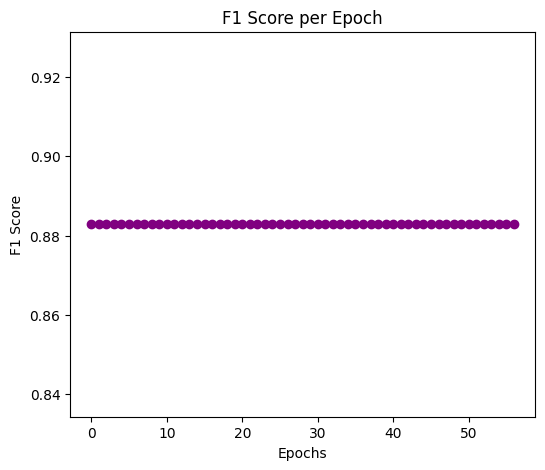

Cohen’s Kappa Score: 0.77
Matthews Correlation Coefficient (MCC): 0.77


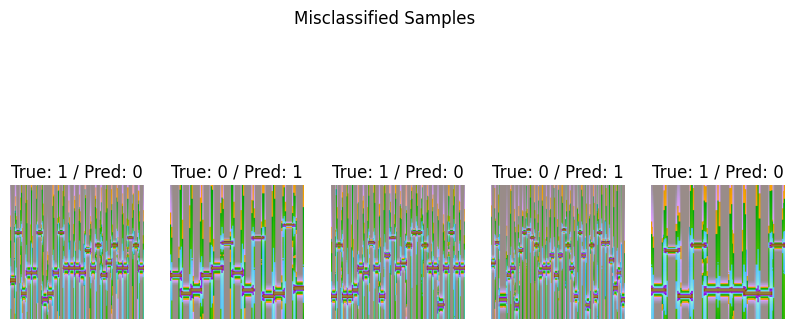


🔟 Performance Metrics Summary Table (For Research Paper)

   Metric  Score
 Accuracy 0.8870
Precision 0.9074
   Recall 0.8596
 F1-score 0.8829
      AUC 0.9153
      MCC 0.7748
   G-mean 0.8863


In [12]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_curve, auc,
    precision_recall_curve, f1_score, cohen_kappa_score, matthews_corrcoef,
    accuracy_score, precision_score, recall_score
)
import pandas as pd
import random

# Predict probabilities and binary labels
y_pred_probs = model.predict(X_test)
y_pred = (y_pred_probs > 0.5).astype(int)

# 🔹 1️⃣ Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Random seq--non-antiviral", "Antiviral"],
            yticklabels=["Random seq--non-antiviral", "Antiviral"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (Ennavia B)")
plt.show()

# 🔹 2️⃣ Classification Report
print("\n🔹 Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=["Random seq--non-antiviral", "Antiviral"]))

# 🔹 3️⃣ ROC Curve & AUC Score
fpr, tpr, _ = roc_curve(y_test, y_pred_probs)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='blue', label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

# 🌟 Extra: AUC Curve with Shaded Area
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.fill_between(fpr, tpr, alpha=0.3, color='blue', label='AUC Area')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('AUC Curve with Shaded Area')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

# 🔹 4️⃣ Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_probs)
plt.figure(figsize=(6, 5))
plt.plot(recall, precision, color='blue', label='Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

# 🔹 5️⃣ Training Loss & Accuracy Curves
plt.figure(figsize=(12, 5))

# Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='red')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy Curve')
plt.legend()
plt.show()

# 🔹 6️⃣ F1 Score per Epoch
f1_scores = [f1_score(y_test, (model.predict(X_test) > 0.5).astype(int)) for _ in range(len(history.history['loss']))]
plt.figure(figsize=(6, 5))
plt.plot(f1_scores, color='purple', marker='o')
plt.xlabel('Epochs')
plt.ylabel('F1 Score')
plt.title('F1 Score per Epoch')
plt.show()

# 🔹 7️⃣ Cohen’s Kappa Score
kappa_score = cohen_kappa_score(y_test, y_pred)
print(f"Cohen’s Kappa Score: {kappa_score:.2f}")

# 🔹 8️⃣ Matthews Correlation Coefficient (MCC)
mcc = matthews_corrcoef(y_test, y_pred)
print(f"Matthews Correlation Coefficient (MCC): {mcc:.2f}")

# 🔹 9️⃣ Error Analysis (Misclassified Samples)
misclassified_idx = np.where(y_pred.flatten() != y_test.flatten())[0]
if len(misclassified_idx) > 5:
    misclassified_idx = random.sample(list(misclassified_idx), 5)

plt.figure(figsize=(10, 5))
for i, idx in enumerate(misclassified_idx):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_test[idx].astype("uint8"))
    plt.title(f"True: {y_test[idx]} / Pred: {y_pred[idx][0]}")
    plt.axis("off")
plt.suptitle("Misclassified Samples")
plt.show()

# 🔟 Performance Metrics Summary Table (for Research Paper)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
accuracy = accuracy_score(y_test, y_pred)
precision_val = precision_score(y_test, y_pred)
recall_val = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
sensitivity = recall_val
specificity = tn / (tn + fp)
gmean = np.sqrt(sensitivity * specificity)

performance_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "AUC", "MCC", "G-mean"],
    "Score": [accuracy, precision_val, recall_val, f1, roc_auc, mcc, gmean]
})

print("\n🔟 Performance Metrics Summary Table (For Research Paper)\n")
print(performance_df.round(4).to_string(index=False))


**inception v3**

In [13]:
import os
import numpy as np
from glob import glob
import cv2
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, applications, regularizers

# Paths to directories (Keep the same dataset paths)
data_dir_train_antiviral = "/kaggle/input/ennavia-b-spectrogram-images-pi-based/spectrogram images/antiviral training images"
data_dir_test_antiviral = "/kaggle/input/ennavia-b-spectrogram-images-pi-based/spectrogram images/antiviral testing images"
,
data_dir_train_non_antiviral = "/kaggle/input/ennavia-b-spectrogram-images-pi-based/spectrogram images/random-seq-non-antiviral training images"
data_dir_test_non_antiviral = "/kaggle/input/ennavia-b-spectrogram-images-pi-based/spectrogram images/random-seq-non-antiviral testing images"

# Image dimensions for InceptionV3
IMG_HEIGHT, IMG_WIDTH = 299, 299  

# Function to load and preprocess images
def load_images_from_directory(directory, label):
    images, labels = [], []
    files = glob(os.path.join(directory, "*.png"))  
    for file in files:
        img = cv2.imread(file)
        if img is None:
            continue
        img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))  
        img = img / 255.0  
        images.append(img)
        labels.append(label)  
    return np.array(images), np.array(labels)

# Load training and testing datasets
X_train_antiviral, y_train_antiviral = load_images_from_directory(data_dir_train_antiviral, label=1)
X_test_antiviral, y_test_antiviral = load_images_from_directory(data_dir_test_antiviral, label=1)

X_train_non_antiviral, y_train_non_antiviral = load_images_from_directory(data_dir_train_non_antiviral, label=0)
X_test_non_antiviral, y_test_non_antiviral = load_images_from_directory(data_dir_test_non_antiviral, label=0)

# Combine both classes
X_train = np.concatenate((X_train_antiviral, X_train_non_antiviral), axis=0)
y_train = np.concatenate((y_train_antiviral, y_train_non_antiviral), axis=0)

X_test = np.concatenate((X_test_antiviral, X_test_non_antiviral), axis=0)
y_test = np.concatenate((y_test_antiviral, y_test_non_antiviral), axis=0)

# Shuffle dataset
indices = np.arange(X_train.shape[0])
np.random.shuffle(indices)
X_train, y_train = X_train[indices], y_train[indices]

indices_test = np.arange(X_test.shape[0])
np.random.shuffle(indices_test)
X_test, y_test = X_test[indices_test], y_test[indices_test]

# Build InceptionV3 Model (Replacing ResNet50)
def build_inception_model(input_shape):
    base_model = applications.InceptionV3(weights='imagenet', include_top=False, input_shape=input_shape)

    # Freeze initial layers, fine-tune last layers
    for layer in base_model.layers[:280]:  
        layer.trainable = False

    inputs = layers.Input(shape=input_shape)
    x = base_model(inputs, training=False)

    # Global Pooling & Dense Layers
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.01))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)  

    model = models.Model(inputs, outputs)

    lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate=0.0001, decay_steps=5000, decay_rate=0.9, staircase=True
    )
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)
    
    model.compile(optimizer=optimizer, 
                  loss='binary_crossentropy', 
                  metrics=['accuracy'])
    return model

# Instantiate InceptionV3 Model
model = build_inception_model((IMG_HEIGHT, IMG_WIDTH, 3))

# Callbacks
early_stopping = callbacks.EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True)
model_checkpoint = callbacks.ModelCheckpoint("best_inception_model.keras", monitor='val_accuracy', save_best_only=True)

# Train Model
history = model.fit(
    X_train, y_train, batch_size=32, epochs=200,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping, model_checkpoint],
    verbose=1
)

# Load best model and evaluate
model.load_weights("best_inception_model.keras")
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy: {test_accuracy * 100:.2f}%")

# Save model in Kaggle
tf.keras.models.save_model(model, "/kaggle/working/final_InceptionV3_model.keras")
print("Model saved successfully in /kaggle/working/")



87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 62s 929ms/step - accuracy: 0.5820 - loss: 5.3363 - val_accuracy: 0.5043 - val_loss: 5.1807
Epoch 2/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 154ms/step - accuracy: 0.7686 - loss: 4.8327 - val_accuracy: 0.5043 - val_loss: 4.8841
Epoch 3/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 6s 191ms/step - accuracy: 0.8491 - loss: 4.5045 - val_accuracy: 0.5391 - val_loss: 4.6721
Epoch 4/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 6s 192ms/step - accuracy: 0.8755 - loss: 4.2958 - val_accuracy: 0.6000 - val_loss: 4.5196
Epoch 5/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 6s 190ms/step - accuracy: 0.9231 - loss: 4.0739 - val_accuracy: 0.8000 - val_loss: 4.2563
Epoch 6/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 6s 190ms/step - accuracy: 0.9716 - loss: 3.8400 - val_accuracy: 0.8609 - val_loss: 4.0260
Epoch 7/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 151ms/step - accuracy: 0.9659 - loss: 3.6884 - val_accuracy: 0.8000 - val_loss: 3.8779
Epoch 8/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 152

4/4 ━━━━━━━━━━━━━━━━━━━━ 14s 3s/step 


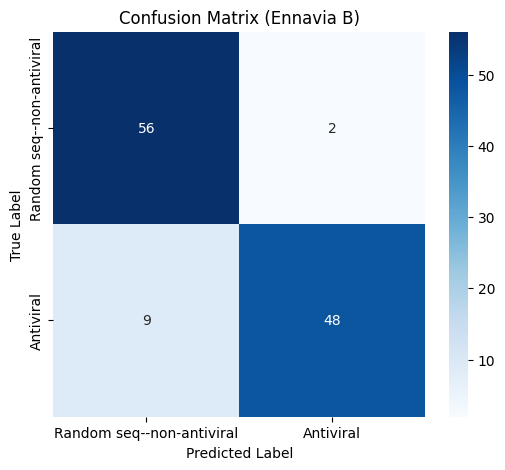


🔹 Classification Report:

                           precision    recall  f1-score   support

Random seq--non-antiviral       0.86      0.97      0.91        58
                Antiviral       0.96      0.84      0.90        57

                 accuracy                           0.90       115
                macro avg       0.91      0.90      0.90       115
             weighted avg       0.91      0.90      0.90       115



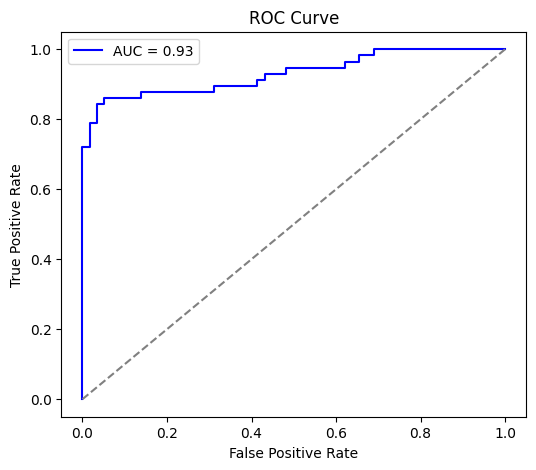

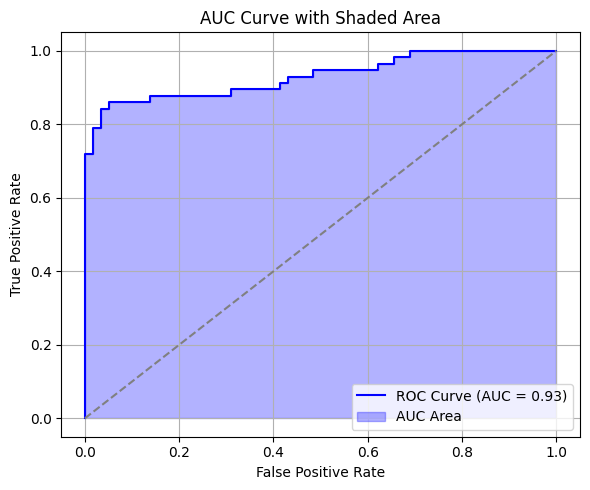

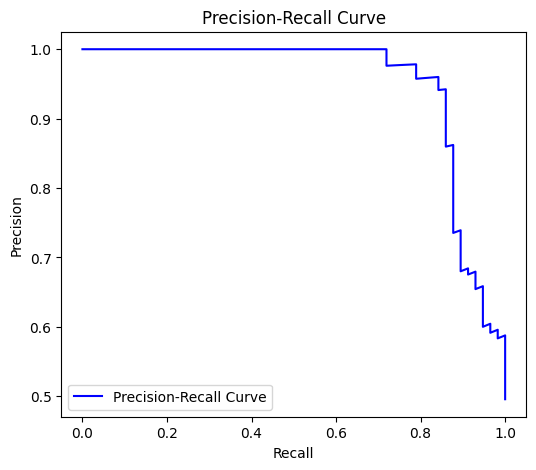

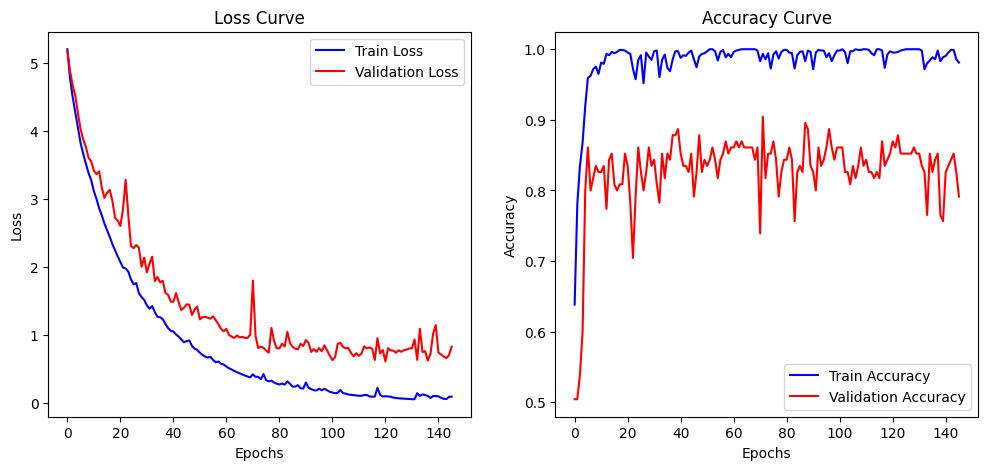

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 

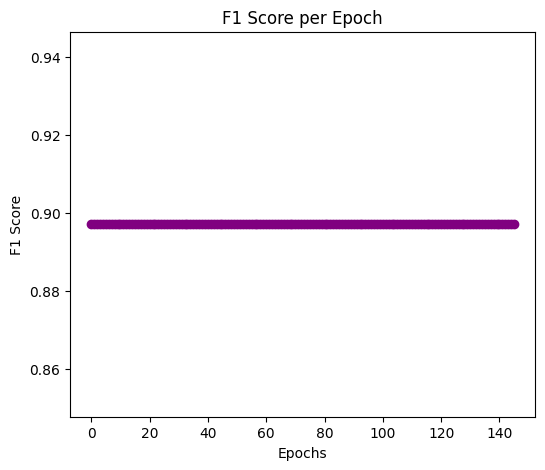

Cohen’s Kappa Score: 0.81
Matthews Correlation Coefficient (MCC): 0.81


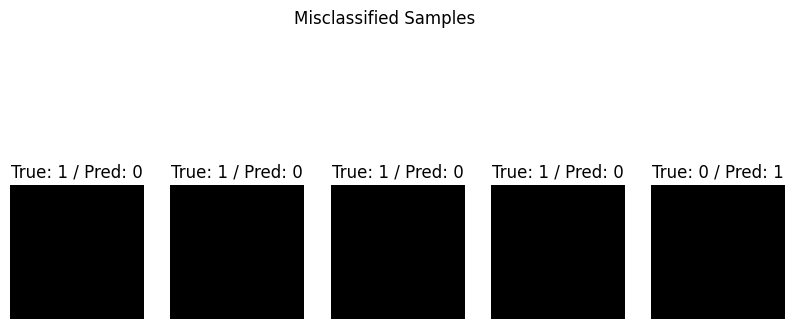


🔟 Performance Metrics Summary Table (For Research Paper)

   Metric  Score
 Accuracy 0.9043
Precision 0.9600
   Recall 0.8421
 F1-score 0.8972
      AUC 0.9304
      MCC 0.8146
   G-mean 0.9017


In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_curve, auc,
    precision_recall_curve, f1_score, cohen_kappa_score, matthews_corrcoef,
    accuracy_score, precision_score, recall_score
)
import pandas as pd
import random

# Predict probabilities and binary labels
y_pred_probs = model.predict(X_test)
y_pred = (y_pred_probs > 0.5).astype(int)

# 🔹 1️⃣ Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Random seq--non-antiviral", "Antiviral"],
            yticklabels=["Random seq--non-antiviral", "Antiviral"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (Ennavia B)")
plt.show()

# 🔹 2️⃣ Classification Report
print("\n🔹 Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=["Random seq--non-antiviral", "Antiviral"]))

# 🔹 3️⃣ ROC Curve & AUC Score
fpr, tpr, _ = roc_curve(y_test, y_pred_probs)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='blue', label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

# 🌟 Extra: AUC Curve with Shaded Area
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.fill_between(fpr, tpr, alpha=0.3, color='blue', label='AUC Area')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('AUC Curve with Shaded Area')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

# 🔹 4️⃣ Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_probs)
plt.figure(figsize=(6, 5))
plt.plot(recall, precision, color='blue', label='Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

# 🔹 5️⃣ Training Loss & Accuracy Curves
plt.figure(figsize=(12, 5))

# Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='red')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy Curve')
plt.legend()
plt.show()

# 🔹 6️⃣ F1 Score per Epoch
f1_scores = [f1_score(y_test, (model.predict(X_test) > 0.5).astype(int)) for _ in range(len(history.history['loss']))]
plt.figure(figsize=(6, 5))
plt.plot(f1_scores, color='purple', marker='o')
plt.xlabel('Epochs')
plt.ylabel('F1 Score')
plt.title('F1 Score per Epoch')
plt.show()

# 🔹 7️⃣ Cohen’s Kappa Score
kappa_score = cohen_kappa_score(y_test, y_pred)
print(f"Cohen’s Kappa Score: {kappa_score:.2f}")

# 🔹 8️⃣ Matthews Correlation Coefficient (MCC)
mcc = matthews_corrcoef(y_test, y_pred)
print(f"Matthews Correlation Coefficient (MCC): {mcc:.2f}")

# 🔹 9️⃣ Error Analysis (Misclassified Samples)
misclassified_idx = np.where(y_pred.flatten() != y_test.flatten())[0]
if len(misclassified_idx) > 5:
    misclassified_idx = random.sample(list(misclassified_idx), 5)

plt.figure(figsize=(10, 5))
for i, idx in enumerate(misclassified_idx):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_test[idx].astype("uint8"))
    plt.title(f"True: {y_test[idx]} / Pred: {y_pred[idx][0]}")
    plt.axis("off")
plt.suptitle("Misclassified Samples")
plt.show()

# 🔟 Performance Metrics Summary Table (for Research Paper)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
accuracy = accuracy_score(y_test, y_pred)
precision_val = precision_score(y_test, y_pred)
recall_val = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
sensitivity = recall_val
specificity = tn / (tn + fp)
gmean = np.sqrt(sensitivity * specificity)

performance_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "AUC", "MCC", "G-mean"],
    "Score": [accuracy, precision_val, recall_val, f1, roc_auc, mcc, gmean]
})

print("\n🔟 Performance Metrics Summary Table (For Research Paper)\n")
print(performance_df.round(4).to_string(index=False))


**inception v3 +SE**

In [15]:
import os
import numpy as np
from glob import glob
import cv2
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.applications.inception_v3 import preprocess_input

# Paths to directories (Modify these paths based on your dataset location)
data_dir_train_antiviral = "/kaggle/input/ennavia-b-spectrogram-images-pi-based/spectrogram images/antiviral training images"
data_dir_test_antiviral = "/kaggle/input/ennavia-b-spectrogram-images-pi-based/spectrogram images/antiviral testing images"
,
data_dir_train_non_antiviral = "/kaggle/input/ennavia-b-spectrogram-images-pi-based/spectrogram images/random-seq-non-antiviral training images"
data_dir_test_non_antiviral = "/kaggle/input/ennavia-b-spectrogram-images-pi-based/spectrogram images/random-seq-non-antiviral testing images"



# Image dimensions
IMG_HEIGHT, IMG_WIDTH = 299, 299  # InceptionV3 input size

# Function to load and preprocess images
def load_images_from_directory(directory, label):
    images, labels = [], []
    files = glob(os.path.join(directory, "*.png"))
    for file in files:
        img = cv2.imread(file)
        if img is None:
            continue
        img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))  
        img = preprocess_input(img)  
        images.append(img)
        labels.append(label)
    return np.array(images), np.array(labels)

# Load datasets
X_train_antiviral, y_train_antiviral = load_images_from_directory(data_dir_train_antiviral, label=1)
X_test_antiviral, y_test_antiviral = load_images_from_directory(data_dir_test_antiviral, label=1)

X_train_non_antiviral, y_train_non_antiviral = load_images_from_directory(data_dir_train_non_antiviral, label=0)
X_test_non_antiviral, y_test_non_antiviral = load_images_from_directory(data_dir_test_non_antiviral, label=0)

# Combine datasets
X_train = np.concatenate((X_train_antiviral, X_train_non_antiviral), axis=0)
y_train = np.concatenate((y_train_antiviral, y_train_non_antiviral), axis=0)

X_test = np.concatenate((X_test_antiviral, X_test_non_antiviral), axis=0)
y_test = np.concatenate((y_test_antiviral, y_test_non_antiviral), axis=0)

# Shuffle datasets
indices = np.arange(X_train.shape[0])
np.random.shuffle(indices)
X_train, y_train = X_train[indices], y_train[indices]

indices_test = np.arange(X_test.shape[0])
np.random.shuffle(indices_test)
X_test, y_test = X_test[indices_test], y_test[indices_test]

# Data Augmentation
datagen = ImageDataGenerator(
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.8, 1.2]
)

# Squeeze-and-Excitation (SE) Attention Block
def se_block(input_tensor, ratio=16):
    """Squeeze-and-Excitation Block"""
    channel = input_tensor.shape[-1]

    # Squeeze: Global Average Pooling
    se = layers.GlobalAveragePooling2D()(input_tensor)
    se = layers.Dense(channel // ratio, activation='relu')(se)  # Bottleneck
    se = layers.Dense(channel, activation='sigmoid')(se)  # Excitation

    se = layers.Reshape((1, 1, channel))(se)  # Reshape for broadcasting
    x = layers.Multiply()([input_tensor, se])  # Apply channel attention
    return x

# Define InceptionV3 Model with SE Attention
def build_inception_se_model(input_shape):
    base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=input_shape)

    # Freeze first layers
    for layer in base_model.layers[:249]:  
        layer.trainable = False
    for layer in base_model.layers[249:]:  
        layer.trainable = True

    # Apply SE Attention to last convolutional block
    x = se_block(base_model.output)

    # Classification Head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.01))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = models.Model(inputs=base_model.input, outputs=outputs)

    # Compile Model with Exponential Decay Learning Rate
    initial_learning_rate = 0.0001
    lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate, decay_steps=10000, decay_rate=0.9, staircase=True)
    
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

    return model

# Instantiate model with SE Attention
model = build_inception_se_model((IMG_HEIGHT, IMG_WIDTH, 3))

# Callbacks
early_stopping = callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
model_checkpoint = callbacks.ModelCheckpoint("best_se_inception_model.keras", monitor='val_accuracy', save_best_only=True)

# Train model
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    epochs=200,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping, model_checkpoint],
    verbose=1
)

# Evaluate Model
model.load_weights("best_se_inception_model.keras")
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy with SE Attention: {test_accuracy * 100:.2f}%")

# Save model in Kaggle
tf.keras.models.save_model(model, "/kaggle/working/final_InceptionV3+SE_model.keras")
print("Model saved successfully in /kaggle/working/")



/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 59s 865ms/step - accuracy: 0.6071 - loss: 8.9097 - val_accuracy: 0.6174 - val_loss: 8.5058
Epoch 2/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 8s 222ms/step - accuracy: 0.7718 - loss: 8.2861 - val_accuracy: 0.5913 - val_loss: 8.1507
Epoch 3/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 9s 254ms/step - accuracy: 0.7906 - loss: 7.8755 - val_accuracy: 0.6609 - val_loss: 7.7942
Epoch 4/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 9s 259ms/step - accuracy: 0.8018 - loss: 7.4872 - val_accuracy: 0.7217 - val_loss: 7.4307
Epoch 5/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 9s 260ms/step - accuracy: 0.8574 - loss: 7.0723 - val_accuracy: 0.8087 - val_loss: 7.0289
Epoch 6/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 9s 257ms/step - accuracy: 0.8836 - loss: 6.7344 - val_accuracy: 0.8435 - val_loss: 6.6718
Epoch 7/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 7s 209ms/step - accuracy: 0.8549 - loss: 6.4790 - val_accuracy: 0.8087 - val_loss: 6.3534
Epoch 8/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 8s 245ms/step - accuracy: 0.9031 - loss: 6.0929 - val_acc

4/4 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step 


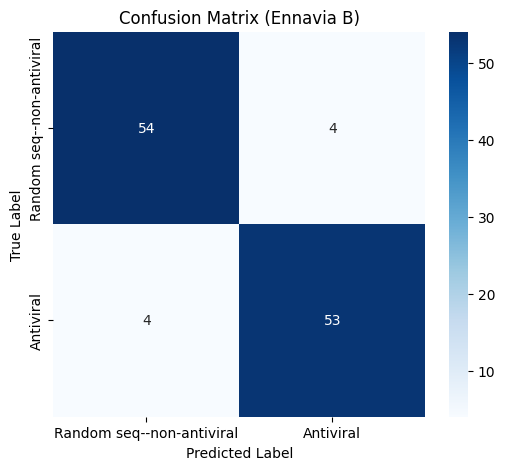


🔹 Classification Report:

                           precision    recall  f1-score   support

Random seq--non-antiviral       0.93      0.93      0.93        58
                Antiviral       0.93      0.93      0.93        57

                 accuracy                           0.93       115
                macro avg       0.93      0.93      0.93       115
             weighted avg       0.93      0.93      0.93       115



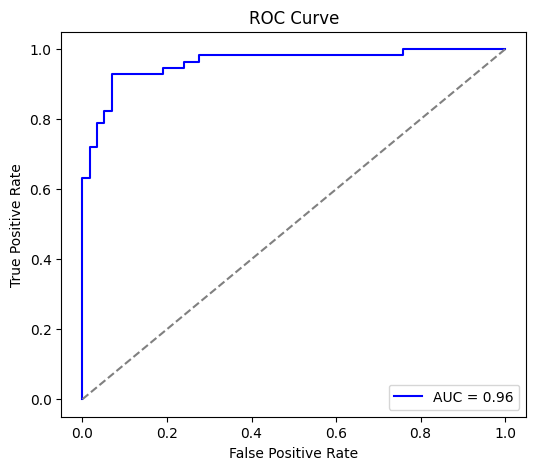

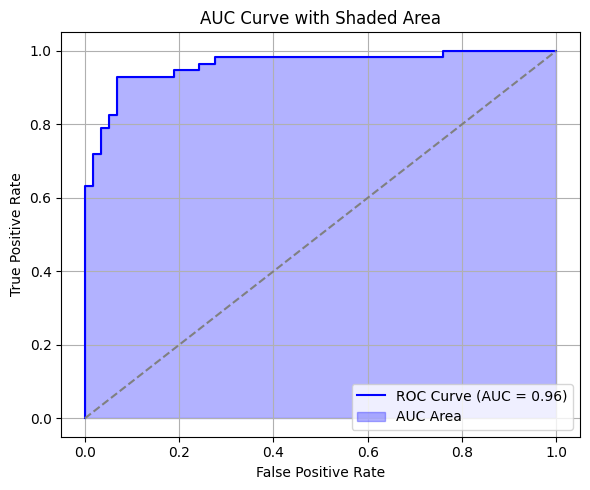

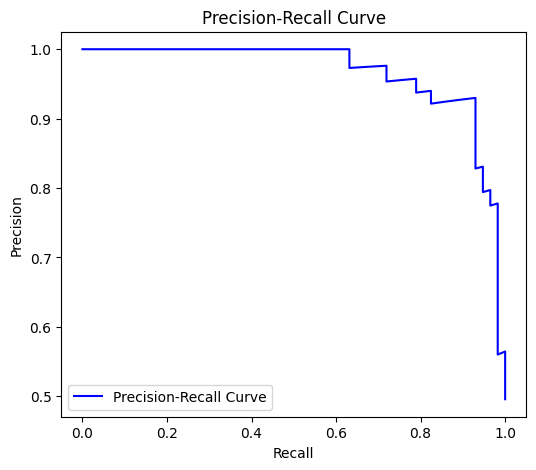

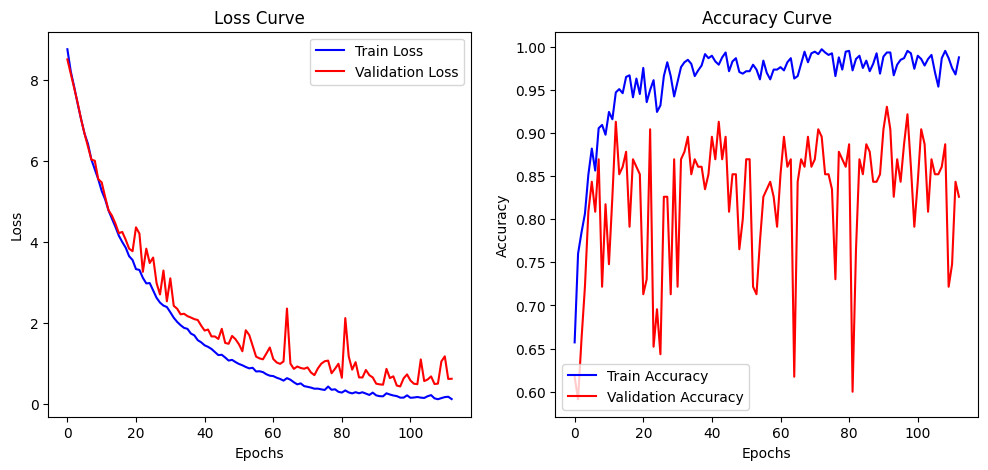

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 

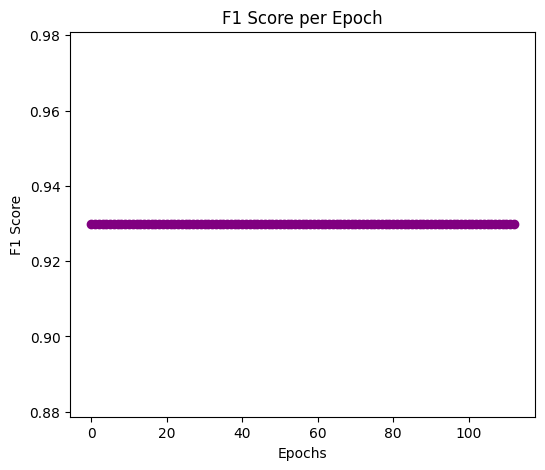

Cohen’s Kappa Score: 0.86
Matthews Correlation Coefficient (MCC): 0.86


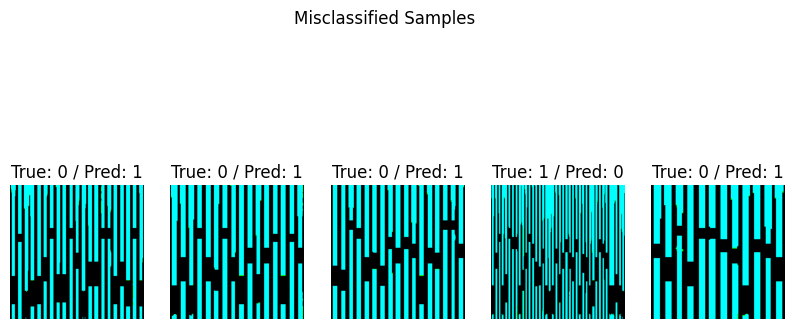


🔟 Performance Metrics Summary Table (For Research Paper)

   Metric  Score
 Accuracy 0.9304
Precision 0.9298
   Recall 0.9298
 F1-score 0.9298
      AUC 0.9613
      MCC 0.8609
   G-mean 0.9304


In [16]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_curve, auc,
    precision_recall_curve, f1_score, cohen_kappa_score, matthews_corrcoef,
    accuracy_score, precision_score, recall_score
)
import pandas as pd
import random

# Predict probabilities and binary labels
y_pred_probs = model.predict(X_test)
y_pred = (y_pred_probs > 0.5).astype(int)

# 🔹 1️⃣ Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Random seq--non-antiviral", "Antiviral"],
            yticklabels=["Random seq--non-antiviral", "Antiviral"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (Ennavia B)")
plt.show()

# 🔹 2️⃣ Classification Report
print("\n🔹 Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=["Random seq--non-antiviral", "Antiviral"]))

# 🔹 3️⃣ ROC Curve & AUC Score
fpr, tpr, _ = roc_curve(y_test, y_pred_probs)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='blue', label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

# 🌟 Extra: AUC Curve with Shaded Area
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.fill_between(fpr, tpr, alpha=0.3, color='blue', label='AUC Area')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('AUC Curve with Shaded Area')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

# 🔹 4️⃣ Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_probs)
plt.figure(figsize=(6, 5))
plt.plot(recall, precision, color='blue', label='Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

# 🔹 5️⃣ Training Loss & Accuracy Curves
plt.figure(figsize=(12, 5))

# Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='red')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy Curve')
plt.legend()
plt.show()

# 🔹 6️⃣ F1 Score per Epoch
f1_scores = [f1_score(y_test, (model.predict(X_test) > 0.5).astype(int)) for _ in range(len(history.history['loss']))]
plt.figure(figsize=(6, 5))
plt.plot(f1_scores, color='purple', marker='o')
plt.xlabel('Epochs')
plt.ylabel('F1 Score')
plt.title('F1 Score per Epoch')
plt.show()

# 🔹 7️⃣ Cohen’s Kappa Score
kappa_score = cohen_kappa_score(y_test, y_pred)
print(f"Cohen’s Kappa Score: {kappa_score:.2f}")

# 🔹 8️⃣ Matthews Correlation Coefficient (MCC)
mcc = matthews_corrcoef(y_test, y_pred)
print(f"Matthews Correlation Coefficient (MCC): {mcc:.2f}")

# 🔹 9️⃣ Error Analysis (Misclassified Samples)
misclassified_idx = np.where(y_pred.flatten() != y_test.flatten())[0]
if len(misclassified_idx) > 5:
    misclassified_idx = random.sample(list(misclassified_idx), 5)

plt.figure(figsize=(10, 5))
for i, idx in enumerate(misclassified_idx):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_test[idx].astype("uint8"))
    plt.title(f"True: {y_test[idx]} / Pred: {y_pred[idx][0]}")
    plt.axis("off")
plt.suptitle("Misclassified Samples")
plt.show()

# 🔟 Performance Metrics Summary Table (for Research Paper)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
accuracy = accuracy_score(y_test, y_pred)
precision_val = precision_score(y_test, y_pred)
recall_val = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
sensitivity = recall_val
specificity = tn / (tn + fp)
gmean = np.sqrt(sensitivity * specificity)

performance_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "AUC", "MCC", "G-mean"],
    "Score": [accuracy, precision_val, recall_val, f1, roc_auc, mcc, gmean]
})

print("\n🔟 Performance Metrics Summary Table (For Research Paper)\n")
print(performance_df.round(4).to_string(index=False))


**inception v3 +CBAM**

In [17]:
import os


import numpy as np
from glob import glob
import cv2
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import layers, models, callbacks, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.applications.inception_v3 import preprocess_input

# Paths to dataset (Modify based on your setup)
data_dir_train_antiviral = "/kaggle/input/ennavia-b-spectrogram-images-pi-based/spectrogram images/antiviral training images"
data_dir_test_antiviral = "/kaggle/input/ennavia-b-spectrogram-images-pi-based/spectrogram images/antiviral testing images"
,
data_dir_train_non_antiviral = "/kaggle/input/ennavia-b-spectrogram-images-pi-based/spectrogram images/random-seq-non-antiviral training images"
data_dir_test_non_antiviral = "/kaggle/input/ennavia-b-spectrogram-images-pi-based/spectrogram images/random-seq-non-antiviral testing images"


# Image dimensions
IMG_HEIGHT, IMG_WIDTH = 299, 299  # InceptionV3 expects 299x299 images

# Function to load and preprocess images
def load_images_from_directory(directory, label):
    images, labels = [], []
    files = glob(os.path.join(directory, "*.png"))  
    for file in files:
        img = cv2.imread(file)
        if img is None:
            continue
        img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))  
        img = preprocess_input(img)  
        images.append(img)
        labels.append(label)  
    return np.array(images), np.array(labels)

# Load dataset
X_train_antiviral, y_train_antiviral = load_images_from_directory(data_dir_train_antiviral, label=1)
X_test_antiviral, y_test_antiviral = load_images_from_directory(data_dir_test_antiviral, label=1)

X_train_non_antiviral, y_train_non_antiviral = load_images_from_directory(data_dir_train_non_antiviral, label=0)
X_test_non_antiviral, y_test_non_antiviral = load_images_from_directory(data_dir_test_non_antiviral, label=0)

# Combine datasets
X_train = np.concatenate((X_train_antiviral, X_train_non_antiviral), axis=0)
y_train = np.concatenate((y_train_antiviral, y_train_non_antiviral), axis=0)

X_test = np.concatenate((X_test_antiviral, X_test_non_antiviral), axis=0)
y_test = np.concatenate((y_test_antiviral, y_test_non_antiviral), axis=0)

# Shuffle dataset
indices = np.arange(X_train.shape[0])
np.random.shuffle(indices)
X_train, y_train = X_train[indices], y_train[indices]

indices_test = np.arange(X_test.shape[0])
np.random.shuffle(indices_test)
X_test, y_test = X_test[indices_test], y_test[indices_test]

# Data Augmentation
datagen = ImageDataGenerator(horizontal_flip=True, vertical_flip=True, brightness_range=[0.8, 1.2])

# CBAM Attention Block
def cbam_block(feature_map, ratio=8):
    """CBAM Attention Mechanism"""
    
    # **Channel Attention**
    channel_avg = layers.GlobalAveragePooling2D()(feature_map)
    channel_max = layers.GlobalMaxPooling2D()(feature_map)
    channel_concat = layers.Concatenate()([channel_avg, channel_max])
    
    channel_dense = layers.Dense(feature_map.shape[-1] // ratio, activation='relu')(channel_concat)
    channel_dense = layers.Dense(feature_map.shape[-1], activation='sigmoid')(channel_dense)
    
    channel_dense = layers.Reshape((1, 1, feature_map.shape[-1]))(channel_dense)  # Reshape for broadcasting
    channel_attention = layers.Multiply()([feature_map, channel_dense])  # Multiply with feature map
    
    # **Spatial Attention**
    spatial_avg = layers.Lambda(lambda x: tf.reduce_mean(x, axis=-1, keepdims=True))(channel_attention)
    spatial_max = layers.Lambda(lambda x: tf.reduce_max(x, axis=-1, keepdims=True))(channel_attention)
    spatial_concat = layers.Concatenate(axis=-1)([spatial_avg, spatial_max])
    
    spatial_attention = layers.Conv2D(1, kernel_size=7, activation='sigmoid', padding='same')(spatial_concat)
    spatial_attention = layers.Multiply()([channel_attention, spatial_attention])
    
    return spatial_attention

# Define InceptionV3 Model with CBAM
def build_inception_cbam_model(input_shape):
    base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=input_shape)

    # Freeze initial layers (up to mixed6, modify as needed for fine-tuning)
    for layer in base_model.layers[:249]:  
        layer.trainable = False
    for layer in base_model.layers[249:]:  
        layer.trainable = True

    # Apply CBAM Attention
    x = cbam_block(base_model.output)

    # Custom classification head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.01))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = models.Model(inputs=base_model.input, outputs=outputs)
    
    # Compile model
    initial_learning_rate = 0.0001
    lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate, decay_steps=10000, decay_rate=0.9, staircase=True)
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)

    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    
    return model

# Instantiate model with CBAM
model = build_inception_cbam_model((IMG_HEIGHT, IMG_WIDTH, 3))

# Callbacks
early_stopping = callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
model_checkpoint = callbacks.ModelCheckpoint("best_cbam_inception_model.keras", monitor='val_accuracy', save_best_only=True)

# Train model
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    epochs=200,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping, model_checkpoint],
    verbose=1
)

# Load best model and evaluate
model.load_weights("best_cbam_inception_model.keras")
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy with CBAM: {test_accuracy * 100:.2f}%")

# Save model in Kaggle
tf.keras.models.save_model(model, "/kaggle/working/final_InceptionV3+CBAM_model.keras")
print("Model saved successfully in /kaggle/working/")


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 62s 928ms/step - accuracy: 0.6185 - loss: 8.7734 - val_accuracy: 0.5130 - val_loss: 8.3579
Epoch 2/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 9s 257ms/step - accuracy: 0.7720 - loss: 8.0160 - val_accuracy: 0.6870 - val_loss: 7.8148
Epoch 3/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 9s 272ms/step - accuracy: 0.8116 - loss: 7.4154 - val_accuracy: 0.7217 - val_loss: 7.2955
Epoch 4/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 9s 272ms/step - accuracy: 0.8039 - loss: 6.9052 - val_accuracy: 0.7652 - val_loss: 6.7960
Epoch 5/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 8s 224ms/step - accuracy: 0.8922 - loss: 6.3086 - val_accuracy: 0.6957 - val_loss: 6.3418
Epoch 6/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 9s 263ms/step - accuracy: 0.9054 - loss: 5.8740 - val_accuracy: 0.7739 - val_loss: 5.8846
Epoch 7/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 8s 223ms/step - accuracy: 0.8880 - loss: 5.4935 - val_accuracy: 0.7304 - val_loss: 5.4824
Epoch 8/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 7s 206ms/step - accuracy: 0.9251 - loss: 5.0358 - val_acc

4/4 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step 


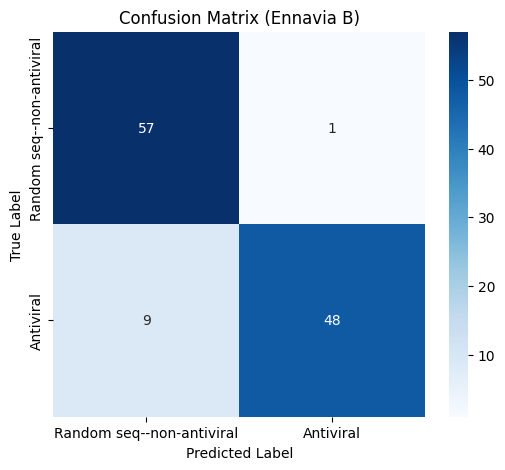


🔹 Classification Report:

                           precision    recall  f1-score   support

Random seq--non-antiviral       0.86      0.98      0.92        58
                Antiviral       0.98      0.84      0.91        57

                 accuracy                           0.91       115
                macro avg       0.92      0.91      0.91       115
             weighted avg       0.92      0.91      0.91       115



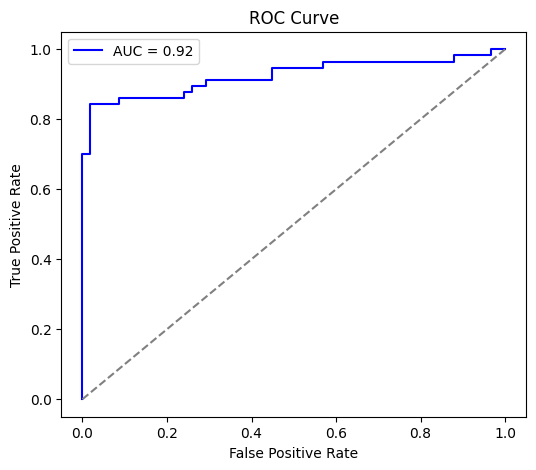

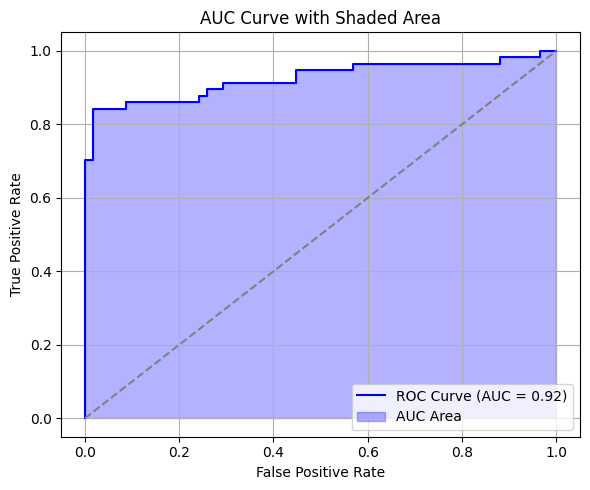

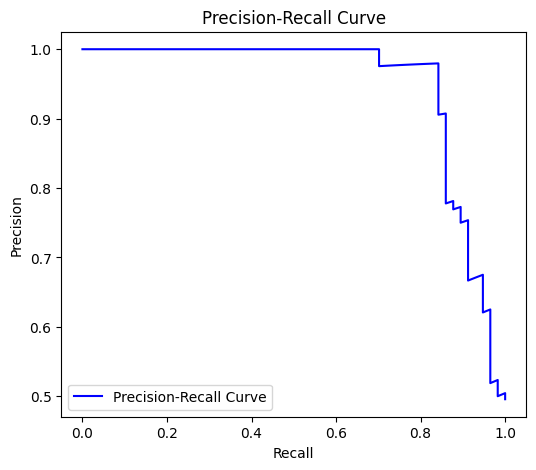

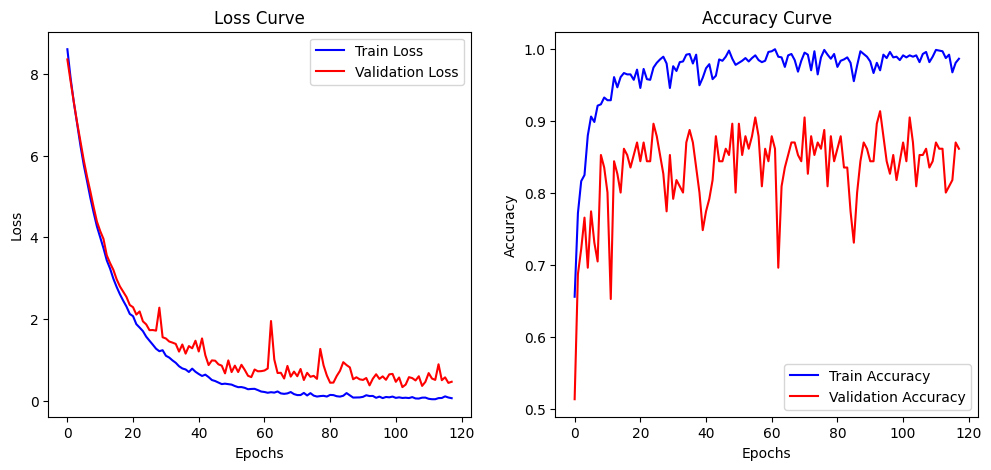

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 

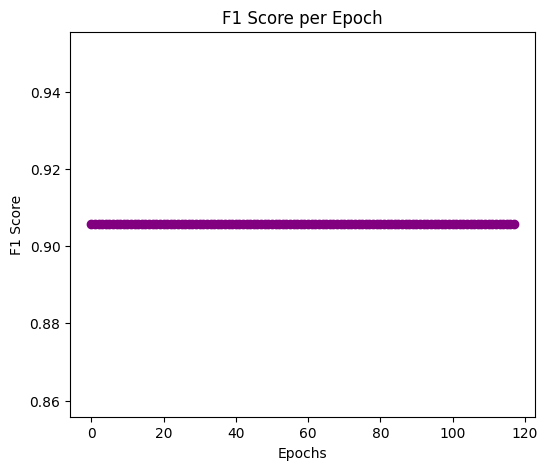

Cohen’s Kappa Score: 0.83
Matthews Correlation Coefficient (MCC): 0.83


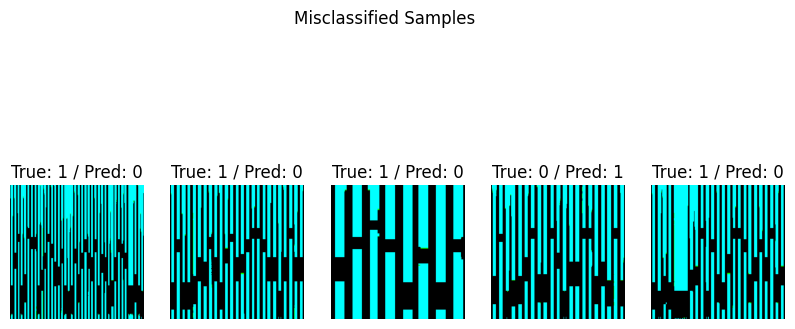


🔟 Performance Metrics Summary Table (For Research Paper)

   Metric  Score
 Accuracy 0.9130
Precision 0.9796
   Recall 0.8421
 F1-score 0.9057
      AUC 0.9241
      MCC 0.8340
   G-mean 0.9097


In [18]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_curve, auc,
    precision_recall_curve, f1_score, cohen_kappa_score, matthews_corrcoef,
    accuracy_score, precision_score, recall_score
)
import pandas as pd
import random

# Predict probabilities and binary labels
y_pred_probs = model.predict(X_test)
y_pred = (y_pred_probs > 0.5).astype(int)

# 🔹 1️⃣ Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Random seq--non-antiviral", "Antiviral"],
            yticklabels=["Random seq--non-antiviral", "Antiviral"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (Ennavia B)")
plt.show()

# 🔹 2️⃣ Classification Report
print("\n🔹 Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=["Random seq--non-antiviral", "Antiviral"]))

# 🔹 3️⃣ ROC Curve & AUC Score
fpr, tpr, _ = roc_curve(y_test, y_pred_probs)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='blue', label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

# 🌟 Extra: AUC Curve with Shaded Area
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.fill_between(fpr, tpr, alpha=0.3, color='blue', label='AUC Area')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('AUC Curve with Shaded Area')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

# 🔹 4️⃣ Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_probs)
plt.figure(figsize=(6, 5))
plt.plot(recall, precision, color='blue', label='Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

# 🔹 5️⃣ Training Loss & Accuracy Curves
plt.figure(figsize=(12, 5))

# Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='red')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy Curve')
plt.legend()
plt.show()

# 🔹 6️⃣ F1 Score per Epoch
f1_scores = [f1_score(y_test, (model.predict(X_test) > 0.5).astype(int)) for _ in range(len(history.history['loss']))]
plt.figure(figsize=(6, 5))
plt.plot(f1_scores, color='purple', marker='o')
plt.xlabel('Epochs')
plt.ylabel('F1 Score')
plt.title('F1 Score per Epoch')
plt.show()

# 🔹 7️⃣ Cohen’s Kappa Score
kappa_score = cohen_kappa_score(y_test, y_pred)
print(f"Cohen’s Kappa Score: {kappa_score:.2f}")

# 🔹 8️⃣ Matthews Correlation Coefficient (MCC)
mcc = matthews_corrcoef(y_test, y_pred)
print(f"Matthews Correlation Coefficient (MCC): {mcc:.2f}")

# 🔹 9️⃣ Error Analysis (Misclassified Samples)
misclassified_idx = np.where(y_pred.flatten() != y_test.flatten())[0]
if len(misclassified_idx) > 5:
    misclassified_idx = random.sample(list(misclassified_idx), 5)

plt.figure(figsize=(10, 5))
for i, idx in enumerate(misclassified_idx):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_test[idx].astype("uint8"))
    plt.title(f"True: {y_test[idx]} / Pred: {y_pred[idx][0]}")
    plt.axis("off")
plt.suptitle("Misclassified Samples")
plt.show()

# 🔟 Performance Metrics Summary Table (for Research Paper)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
accuracy = accuracy_score(y_test, y_pred)
precision_val = precision_score(y_test, y_pred)
recall_val = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
sensitivity = recall_val
specificity = tn / (tn + fp)
gmean = np.sqrt(sensitivity * specificity)

performance_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "AUC", "MCC", "G-mean"],
    "Score": [accuracy, precision_val, recall_val, f1, roc_auc, mcc, gmean]
})

print("\n🔟 Performance Metrics Summary Table (For Research Paper)\n")
print(performance_df.round(4).to_string(index=False))
